# Meliora in practice
## 29 investigations of credit-risk models

A useful validation example starts with a question, makes the evidence visible, and
ends with a conclusion that the statistic actually supports. This notebook gives
every Meliora test or measure a full example, in the handbook's order. Every example
includes a graph, the Meliora call, numerical results, and a suggested experiment.

The main cases contain **8,000 obligors across eight PD grades** and **600 completed
default episodes across three LGD segments**. Additional cases use 24 annual observations,
an 8 × 8 migration matrix built from 8,000 transitions, and deliberately constructed
counterexamples. All data are synthetic. Counts, biases and forecasts are specified
for teaching; none is evidence about a real lender or a regulatory acceptance rule.

**Reading paths**

| Area | Examples | Main question |
|---|---|---|
| [Discrimination](#discrimination) | 1–9 | What does good ordering tell us—and what can it hide? |
| [PD calibration](#calibration) | 10–16 | Where are forecasts systematically wrong? |
| [LGD association](#association) | 17–20 | Do ties, direction, curvature or influential points change the story? |
| [Stability](#stability) | 21–25 | Has the portfolio moved, concentrated or started jumping grades? |
| [LGD validation](#lgd-validation) | 26–29 | Do average or monetary totals hide individual errors? |

### Run this notebook

Clone the repository and open this notebook directly from the checkout:

```bash
git clone https://github.com/at621/meliora.git
cd meliora
python -m jupyter lab docs/examples/detailed_examples.ipynb
```

Use a Python 3.11+ environment with NumPy, pandas, SciPy, scikit-learn, Matplotlib
and JupyterLab available. The setup cell locates Meliora in the cloned repository.
Select that environment as the notebook kernel, then **Restart Kernel and Run All**.
The saved outputs also make the notebook readable on GitHub without running it.
Run the setup cells below once; after that, each numbered example can run independently.
No downloads, external data files or network calls are needed during execution.

PD and LGD are fractions (0.05 means 5%); EAD is exposure at default, in euros.
Higher grades and scores mean higher risk or loss. Comparisons always use the same
observations unless a change of sample is explicitly the subject of the example.
Tests use 5% where relevant, with the tail convention stated locally. Descriptive
measures have no pass/fail threshold. Grade and segment tests are unadjusted for
multiple comparisons; a non-rejection is not proof that a model is adequate.

In [1]:
from pathlib import Path
import sys
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from scipy import stats, special
from sklearn.metrics import roc_curve
from IPython.display import display, Markdown

# Prefer this checkout when launched either at the repository root or inside docs.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "meliora/core.py").is_file():
        sys.path.insert(0, str(candidate))
        break
import meliora as m

BLUE, ORANGE, TEAL, GREY = "#245B85", "#C65D32", "#23887F", "#7C8794"
plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 115,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.16, "axes.axisbelow": True,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, TEAL, GREY]),
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_rows", 30)

def table(frame, formats=None, caption=None):
    styled = frame.style.format(formats or {}, na_rep="—", precision=4)
    if caption:
        styled = styled.set_caption(caption)
    display(styled)

def report(text):
    display(Markdown("**Result.** " + text))

def finish(fig):
    fig.tight_layout()
    plt.show()

def percent(ax, axis="y"):
    getattr(ax, axis + "axis").set_major_formatter(PercentFormatter(1))

def expand_grades(spec, seed=20260912):
    """Expand disclosed grade counts to individual rows; shuffle outcomes within grade."""
    rng = np.random.default_rng(seed)
    rows = []
    for row in spec.itertuples(index=False):
        outcomes = np.r_[np.ones(int(row.defaults), dtype=int),
                         np.zeros(int(row.n - row.defaults), dtype=int)]
        rng.shuffle(outcomes)
        rows.append(pd.DataFrame({"grade": row.grade, "default": outcomes, "pd": row.pd}))
    return pd.concat(rows, ignore_index=True)

def grade_frame(counts, labels):
    return pd.DataFrame({"grade": np.repeat(labels, np.asarray(counts, dtype=int))})

def expand_migrations(counts, labels):
    rows = [pd.DataFrame({"start": labels[i], "end": labels[j]}, index=range(int(n)))
            for i, row in enumerate(counts) for j, n in enumerate(row) if n]
    return pd.concat(rows, ignore_index=True)

def capture_curve(data, score):
    # Pool ties before integrating: no arbitrary order within a tied score band.
    bands = data.assign(loss=data.ead * data.realised).groupby(score)[["ead", "loss"]].sum()
    bands = bands.sort_index(ascending=False)
    return (np.r_[0, bands.ead.cumsum() / bands.ead.sum()],
            np.r_[0, bands.loss.cumsum() / bands.loss.sum()])

def heatmap(ax, values, rows, columns, title, *, fmt=".0f", cmap="Blues", vmin=None, vmax=None):
    values = np.asarray(values, dtype=float)
    artist = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.grid(False)
    ax.set(xticks=range(len(columns)), xticklabels=columns,
           yticks=range(len(rows)), yticklabels=rows, title=title)
    midpoint = (artist.norm.vmin + artist.norm.vmax) / 2
    for i, j in np.ndindex(values.shape):
        value = values[i, j]
        ax.text(j, i, "—" if np.isnan(value) else format(value, fmt), ha="center", va="center",
                fontsize=8, color="white" if np.isfinite(value) and value > midpoint else "#253648")
    return artist

versions = {name: importlib.metadata.version(name)
            for name in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib"]}
print(f"Python {sys.version.split()[0]} | Meliora {m.__version__}")
print(" | ".join(f"{name} {version}" for name, version in versions.items()))

Python 3.13.1 | Meliora 0.3
numpy 2.2.4 | pandas 2.2.3 | scipy 1.17.1 | scikit-learn 1.6.1 | matplotlib 3.10.1


### The PD cohort: eight grades, 8,000 obligors

Each row after expansion is one obligor's one-year outcome. The grade forecasts below
are fixed inputs, with a common PD inside each grade. Default counts are deliberately
chosen to create a credible risk gradient and some underestimation. Shuffling only
sets row order; it does not change the counts or fit a model. The alternative forecast
is a pre-specified 50% uplift, used to distinguish calibration from ranking.

In [2]:
GRADES = list("ABCDEFGH")
pd_spec = pd.DataFrame({
    "grade": GRADES,
    "n": [2200, 1900, 1400, 1000, 700, 450, 250, 100],
    "defaults": [11, 22, 33, 48, 49, 54, 48, 35],
    "pd": [.004, .008, .015, .030, .055, .095, .160, .260],
})
pd_spec["observed_rate"] = pd_spec.defaults / pd_spec.n
pd_spec["expected_defaults"] = pd_spec.n * pd_spec.pd
pd_portfolio = expand_grades(pd_spec)
pd_portfolio["pd_uplift"] = 1.5 * pd_portfolio.pd
pd_portfolio["grade_number"] = pd_portfolio.grade.map({g: i for i, g in enumerate(GRADES)})
table(pd_spec.set_index("grade"), {"pd": "{:.2%}", "observed_rate": "{:.2%}",
                                   "expected_defaults": "{:.1f}"}, "Main PD input data")
print(f"{len(pd_portfolio):,} obligors; {pd_portfolio.default.sum():,} defaults; "
      f"observed default rate {pd_portfolio.default.mean():.2%}.")
display(pd_portfolio.sample(6, random_state=12).sort_index())

,n,defaults,pd,observed_rate,expected_defaults
grade,,,,,
A,2200,11,0.40%,0.50%,8.8
B,1900,22,0.80%,1.16%,15.2
C,1400,33,1.50%,2.36%,21.0
D,1000,48,3.00%,4.80%,30.0
E,700,49,5.50%,7.00%,38.5
F,450,54,9.50%,12.00%,42.8
G,250,48,16.00%,19.20%,40.0
H,100,35,26.00%,35.00%,26.0


8,000 obligors; 300 defaults; observed default rate 3.75%.


,grade,default,pd,pd_uplift,grade_number
1091,A,0,0.004,0.0060,0
1564,A,0,0.004,0.0060,0
2110,A,0,0.004,0.0060,0
4662,C,0,0.015,0.0225,2
5754,D,0,0.030,0.0450,3
6447,D,0,0.030,0.0450,3


### The LGD cohort: 600 completed default episodes

There are 200 facilities in each segment. Predicted LGDs vary within the segments;
realised losses add random dispersion and a deliberately imposed segment mean error
of +6, −6 or 0 percentage points. Errors are centred within segment to make cancellation
exact and easy to inspect. This construction illustrates a mechanism, not the sampling
power of the tests. For inferential interpretation, actual facility errors would need
to be independent observations from the relevant population.

The segment with underestimation has larger exposures. This will let us compare an
equal-facility test with monetary loss measures. No scenario is estimated from a real
validation sample; all random generators use fixed local seeds.

In [3]:
rng_lgd = np.random.default_rng(73)
parts = []
for segment, centre, bias, typical_ead in [
    ("Commercial secured", .30, .06, 900_000),
    ("Unsecured retail", .50, -.06, 150_000),
    ("SME", .70, .00, 300_000),
]:
    predicted = centre + rng_lgd.uniform(-.14, .14, 200)
    noise = rng_lgd.uniform(-.09, .09, 200)
    error = noise - noise.mean() + bias
    parts.append(pd.DataFrame({
        "segment": segment, "predicted": predicted, "realised": predicted + error,
        "ead": np.round(rng_lgd.lognormal(np.log(typical_ead), .65, 200), -2),
    }))
lgd = pd.concat(parts, ignore_index=True)
lgd["facility_id"] = np.arange(1, len(lgd) + 1)
lgd["pred_grade"] = np.digitize(lgd.predicted, [.2, .4, .6, .8]) + 1
lgd["real_grade"] = np.digitize(lgd.realised, [.2, .4, .6, .8]) + 1
lgd_summary = lgd.assign(error=lgd.realised - lgd.predicted).groupby("segment", sort=False).agg(
    facilities=("facility_id", "size"), total_ead=("ead", "sum"),
    predicted_mean=("predicted", "mean"), realised_mean=("realised", "mean"),
    mean_error=("error", "mean"),
)
table(lgd_summary, {"total_ead": "€{:,.0f}", "predicted_mean": "{:.1%}",
                    "realised_mean": "{:.1%}", "mean_error": "{:+.1%}"}, "Main LGD input data")
display(lgd.sample(6, random_state=12).round(3))

,facilities,total_ead,predicted_mean,realised_mean,mean_error
segment,,,,,
Commercial secured,200,"€230,956,300",30.1%,36.1%,+6.0%
Unsecured retail,200,"€36,403,200",50.2%,44.2%,-6.0%
SME,200,"€74,629,000",70.3%,70.3%,-0.0%


,segment,predicted,realised,ead,facility_id,pred_grade,real_grade
326,Unsecured retail,0.510,0.431,229500.0,327,3,3
360,Unsecured retail,0.408,0.365,73100.0,361,3,2
348,Unsecured retail,0.594,0.462,309300.0,349,3,3
567,SME,0.806,0.866,208500.0,568,5,5
244,Unsecured retail,0.552,0.458,189400.0,245,3,3
294,Unsecured retail,0.447,0.397,134300.0,295,3,2


<a id="discrimination"></a>
## Discrimination

Start with ordering, then examine what an ordering measure leaves out.

<a id="example-01"></a>
### 1. ROC AUC — what is lost when eight grades become three?

**Question.** How much ranking information disappears when operational reporting collapses the grade scale?

Use all 8,000 obligors. The eight-grade score is the original PD; the three-band score merges A–C, D–F and G–H. The coarser system creates ties between obligors that the original system distinguished. Both curves use higher scores for higher default risk.

[API, formula and statistical sources](../reference/roc_auc.md).

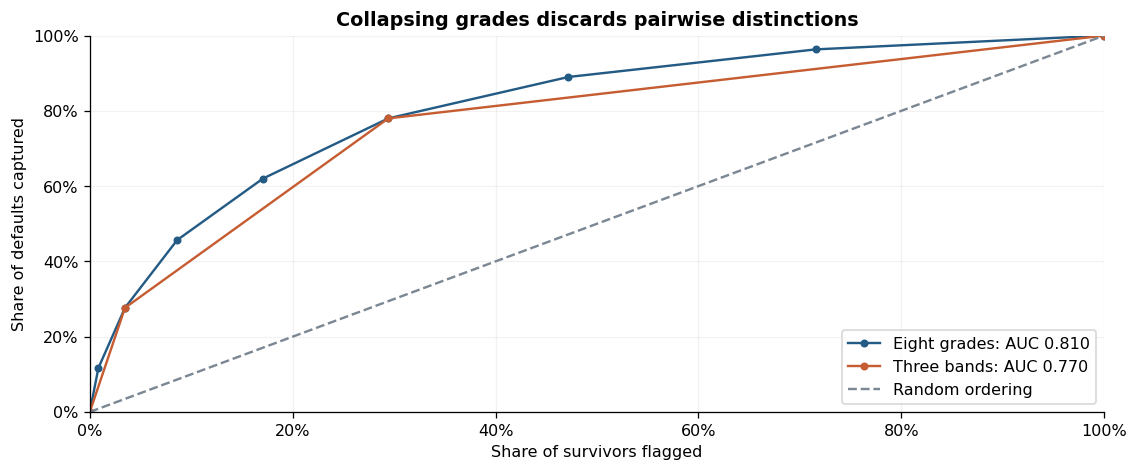

,distinct_scores,AUC
score,,
Eight grades,8,0.8099
Three bands,3,0.7700


**Result.** Merging the grades changes AUC by -0.040. Tied defaulter–survivor pairs receive half credit.

In [4]:
data = pd_portfolio.copy()
data["three_bands"] = pd.cut(data.grade_number, [-1, 2, 5, 7], labels=[0, 1, 2]).astype(int)
results = []
fig, ax = plt.subplots()
for label, column in [("Eight grades", "pd"), ("Three bands", "three_bands")]:
    auc = m.roc_auc(data, "default", column)
    fpr, tpr, _ = roc_curve(data.default, data[column])
    ax.plot(fpr, tpr, marker="o", ms=4, label=f"{label}: AUC {auc:.3f}")
    results.append({"score": label, "distinct_scores": data[column].nunique(), "AUC": auc})
ax.plot([0, 1], [0, 1], "--", color=GREY, label="Random ordering")
ax.set(xlabel="Share of survivors flagged", ylabel="Share of defaults captured",
       title="Collapsing grades discards pairwise distinctions", xlim=(0, 1), ylim=(0, 1))
percent(ax, "x"); percent(ax)
ax.legend(loc="lower right")
finish(fig)
table(pd.DataFrame(results).set_index("score"))
report(f"Merging the grades changes AUC by {results[1]['AUC'] - results[0]['AUC']:+.3f}. "
       "Tied defaulter–survivor pairs receive half credit.")

**What this shows.** The graph quantifies the information lost by this particular pooling scheme. AUC is a ranking probability, so it does not test whether the PD levels are correct. More grades are useful only when their distinctions carry information on new observations.

**Try changing:** the cut points in `pd.cut`; compare pooling the safest grades with pooling the riskiest grades.

<a id="example-02"></a>
### 2. Gini — identical ranking, different probabilities

**Question.** Can a 50% PD uplift improve the Gini coefficient?

Compare the original forecast, its 50% uplift, and an accidentally reversed score on the same 8,000 outcomes. The uplift changes every probability but preserves all ranks. The reversed score models a common direction-convention mistake.

[API, formula and statistical sources](../reference/gini.md).

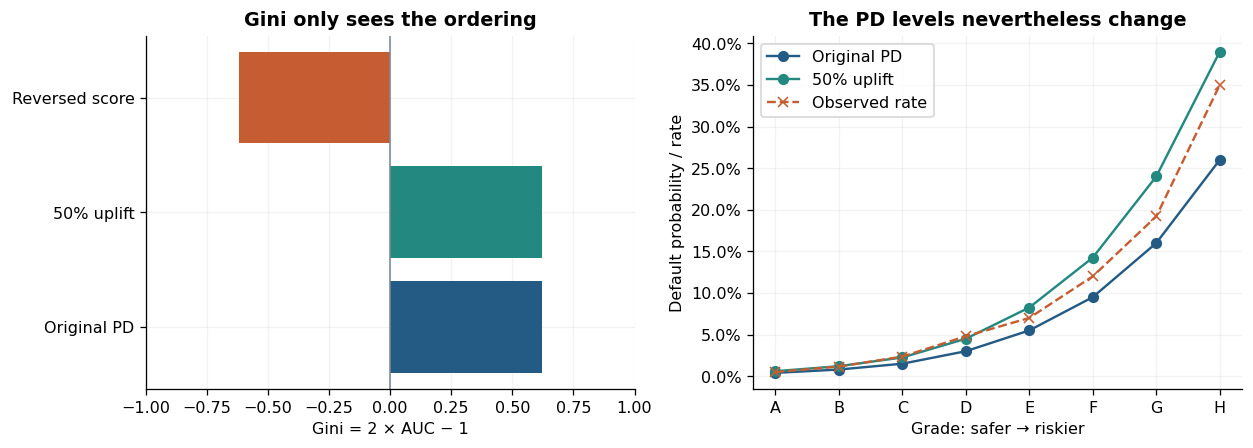

,Gini
Original PD,0.6198
50% uplift,0.6198
Reversed score,-0.6198


**Result.** Original and uplifted PDs both give Gini 0.620; reversing the score gives -0.620.

In [5]:
data = pd_portfolio.assign(reversed_score=-pd_portfolio.pd)
values = pd.Series({
    "Original PD": m.gini(data, "default", "pd"),
    "50% uplift": m.gini(data, "default", "pd_uplift"),
    "Reversed score": m.gini(data, "default", "reversed_score"),
}, name="Gini")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(values.index, values, color=[BLUE, TEAL, ORANGE])
axes[0].axvline(0, color=GREY, lw=1)
axes[0].set(xlim=(-1, 1), xlabel="Gini = 2 × AUC − 1", title="Gini only sees the ordering")
axes[1].plot(GRADES, pd_spec.pd, "o-", label="Original PD")
axes[1].plot(GRADES, 1.5 * pd_spec.pd, "o-", color=TEAL, label="50% uplift")
axes[1].plot(GRADES, pd_spec.observed_rate, "x--", color=ORANGE, label="Observed rate")
axes[1].set(xlabel="Grade: safer → riskier", ylabel="Default probability / rate",
            title="The PD levels nevertheless change")
percent(axes[1]); axes[1].legend()
finish(fig)
table(values.to_frame())
report(f"Original and uplifted PDs both give Gini {values.iloc[0]:.3f}; reversing the "
       f"score gives {values.iloc[2]:.3f}.")

**What this shows.** Gini adds no calibration information to AUC. A negative value can indicate reversed score direction; verify the convention before treating it as a model failure. Use calibration tests and a proper scoring rule to assess a PD-level adjustment.

**Try changing:** the uplift factor while keeping all PDs below 1; observe which quantities move.

<a id="example-03"></a>
### 3. Kolmogorov–Smirnov — separation is not an operating policy

**Question.** At which grade boundary are survivor and defaulter distributions furthest apart?

Draw empirical cumulative distributions for all survivors and defaults. The largest vertical gap identifies a separation boundary. A KS test compares distributions; it does not use the financial costs of a false alarm or a missed default.

[API, formula and statistical sources](../reference/kolmogorov_smirnov_stat.md).

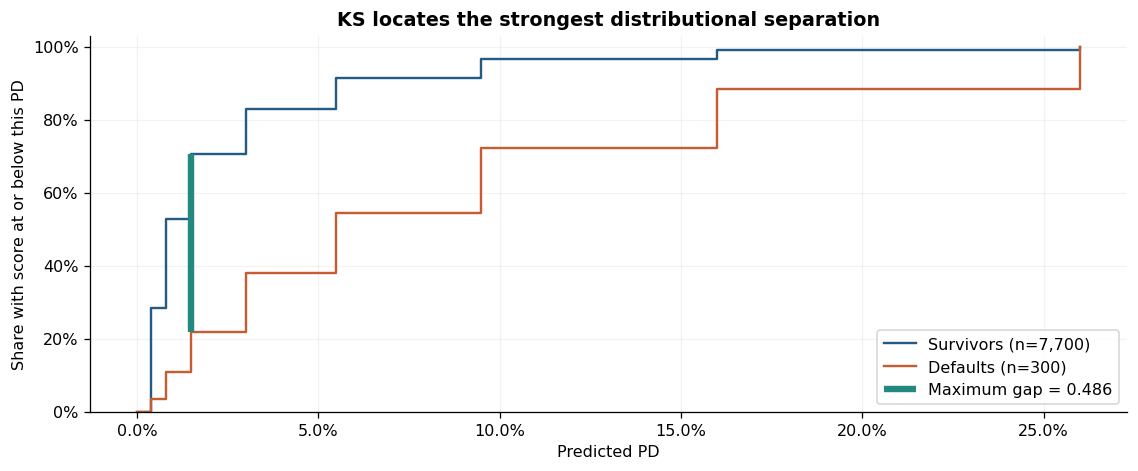

**Result.** KS = 0.486, two-sided p = 4.08e-63; the largest gap is after PD 1.50%. Negating the score leaves KS unchanged: 0.486.

In [6]:
data = pd_portfolio.copy()
result = m.kolmogorov_smirnov_stat(data, "default", "pd")
thresholds = np.r_[0, np.sort(data.pd.unique())]
survivors = data.loc[data.default == 0, "pd"].to_numpy()
defaults = data.loc[data.default == 1, "pd"].to_numpy()
cdf_survivors = np.array([(survivors <= t).mean() for t in thresholds])
cdf_defaults = np.array([(defaults <= t).mean() for t in thresholds])
index = np.argmax(np.abs(cdf_survivors - cdf_defaults))
cutoff = thresholds[index]
fig, ax = plt.subplots()
ax.step(thresholds, cdf_survivors, where="post", label=f"Survivors (n={len(survivors):,})")
ax.step(thresholds, cdf_defaults, where="post", label=f"Defaults (n={len(defaults):,})")
ax.vlines(cutoff, cdf_defaults[index], cdf_survivors[index], color=TEAL, lw=4,
          label=f"Maximum gap = {result.statistic:.3f}")
ax.set(xlabel="Predicted PD", ylabel="Share with score at or below this PD",
       title="KS locates the strongest distributional separation", ylim=(0, 1.03))
percent(ax, "x"); percent(ax); ax.legend(loc="lower right")
finish(fig)
report(f"KS = {result.statistic:.3f}, two-sided p = {result.pvalue:.3g}; the largest "
       f"gap is after PD {cutoff:.2%}. Negating the score leaves KS unchanged: "
       f"{m.kolmogorov_smirnov_stat(data.assign(reverse=-data.pd), 'default', 'reverse').statistic:.3f}.")

**What this shows.** A sizeable gap says the distributions differ, but its p-value is neither the size of the business benefit nor evidence that a particular cut-off is optimal. The discrete grade scores contain ties; the conventional KS p-value needs caution because continuous-null calibration does not directly apply to a tied score scale.

**Try changing:** the score column to `pd_uplift`; the numerical boundary moves while the maximum gap stays the same.

<a id="example-04"></a>
### 4. Minimum threshold error — 96% accuracy can miss every default

**Question.** What does minimising mistakes recommend when defaults are rare?

The historical API name is `bayesian_error_rate`, but this function is an empirical minimum over score cut-offs. It gives false positives and false negatives equal cost. Compare that rule with a scenario where missing a default costs 20 times as much as reviewing a survivor; the multiplier is illustrative.

[API, formula and statistical sources](../reference/bayesian_error_rate.md).

,flag if PD ≥,reviewed,missed defaults,false alarms,error rate,cost per obligor
rule,,,,,,
Equal-cost minimum,Flag nobody,0,300,0,3.75%,0.7500
20:1 cost minimum,3.00%,2500,66,2266,29.15%,0.4482


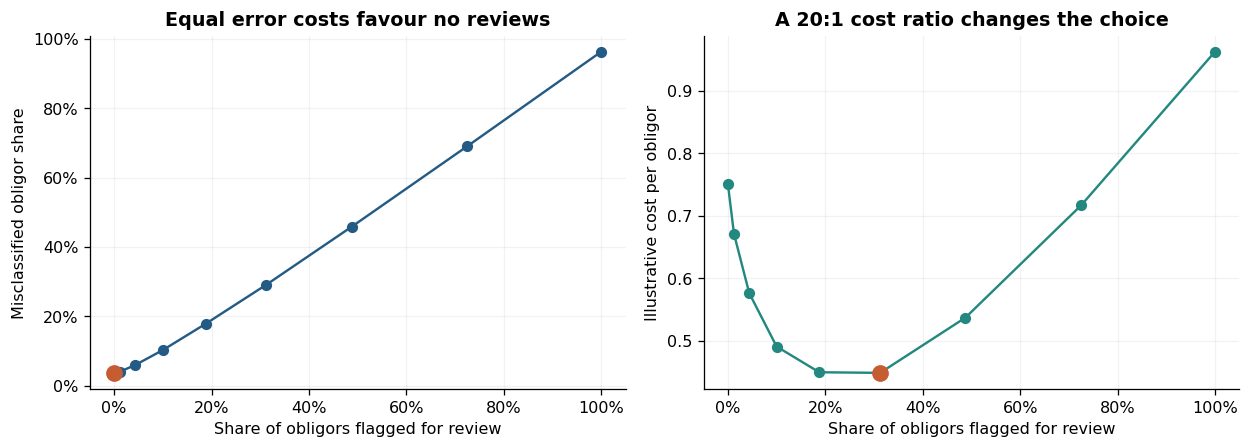

**Result.** Meliora's minimum error is 3.75%: accuracy is 96.25%, yet 300 of 300 defaults are missed by that rule.

In [7]:
data = pd_portfolio.copy()
fpr, tpr, thresholds = roc_curve(data.default, data.pd, drop_intermediate=False)
n_bad, n_good = int(data.default.sum()), int((1 - data.default).sum())
fp, fn = np.rint(fpr * n_good).astype(int), np.rint((1 - tpr) * n_bad).astype(int)
flagged = fp + n_bad - fn
equal_error = (fp + fn) / len(data)
missed_default_cost = 20
weighted_cost = (fp + missed_default_cost * fn) / len(data)
i_equal, i_cost = np.argmin(equal_error), np.argmin(weighted_cost)
minimum = m.bayesian_error_rate(data, "default", "pd")
rows = []
for label, index in [("Equal-cost minimum", i_equal), ("20:1 cost minimum", i_cost)]:
    rows.append({"rule": label,
                 "flag if PD ≥": "Flag nobody" if np.isinf(thresholds[index]) else f"{thresholds[index]:.2%}",
                 "reviewed": flagged[index], "missed defaults": fn[index],
                 "false alarms": fp[index], "error rate": equal_error[index],
                 "cost per obligor": weighted_cost[index]})
table(pd.DataFrame(rows).set_index("rule"), {"error rate": "{:.2%}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(flagged / len(data), equal_error, "o-")
axes[0].scatter(flagged[i_equal] / len(data), equal_error[i_equal], color=ORANGE, s=90, zorder=3)
axes[0].set(title="Equal error costs favour no reviews", ylabel="Misclassified obligor share")
axes[1].plot(flagged / len(data), weighted_cost, "o-", color=TEAL)
axes[1].scatter(flagged[i_cost] / len(data), weighted_cost[i_cost], color=ORANGE, s=90, zorder=3)
axes[1].set(title="A 20:1 cost ratio changes the choice", ylabel="Illustrative cost per obligor")
for ax in axes:
    ax.set_xlabel("Share of obligors flagged for review"); percent(ax, "x")
percent(axes[0]); finish(fig)
report(f"Meliora's minimum error is {minimum:.2%}: accuracy is {1-minimum:.2%}, "
       f"yet {fn[i_equal]} of {n_bad} defaults are missed by that rule.")

**What this shows.** Overall accuracy can reward a useless rare-event policy. Select a decision rule using capacity and credible error costs, and report default recall as well as error rate. These cut-offs are selected on the displayed sample; they need separate validation before estimating future operating performance.

**Try changing:** `missed_default_cost` to 5 or 50 and inspect both the review volume and the missed defaults.

<a id="example-05"></a>
### 5. Information value — which grades carry the signal?

**Question.** Does the IV total conceal dependence on a sparse, zero-default bin?

Add 40 synthetic zero-default accounts in a new safest bin A0 to the 8,000-obligor cohort. Show counts, survivor/default shares, weight of evidence and contributions for all nine bins. Positive smoothing is required because A0 has no defaults.

[API, formula and statistical sources](../reference/information_value.md).

,good,bad,good_share,bad_share,WoE,IV
grade,,,,,,
A0,40.0000,0.0000,0.52%,0.16%,1.1584,0.0042
A,2189.0000,11.0000,28.27%,3.78%,2.0130,0.4931
B,1878.0000,22.0000,24.26%,7.39%,1.1886,0.2005
C,1367.0000,33.0000,17.66%,11.00%,0.4731,0.0315
D,952.0000,48.0000,12.30%,15.93%,-0.2585,0.0094
E,651.0000,49.0000,8.41%,16.26%,-0.6588,0.0517
F,396.0000,54.0000,5.12%,17.90%,-1.2516,0.1599
G,202.0000,48.0000,2.61%,15.93%,-1.8069,0.2406
H,65.0000,35.0000,0.85%,11.66%,-2.6235,0.2837


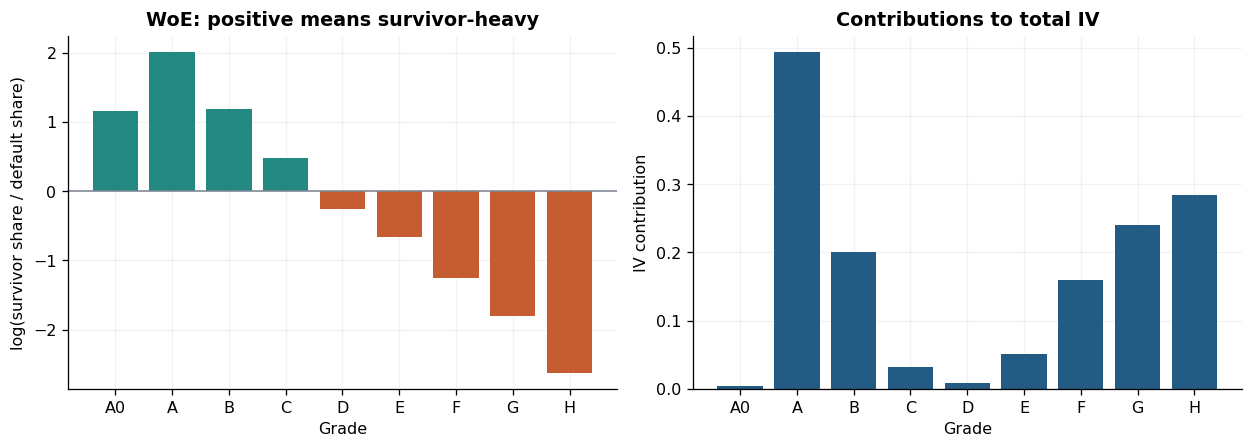

,IV,A0 contribution
pseudo-count per class/bin,,
0.100000,1.4986,0.0133
0.500000,1.4744,0.0042
1.000000,1.4533,0.0010


**Result.** Smoothed IV is 1.474; A0 contributes 0.3% of it.

In [8]:
sparse = pd.DataFrame({"grade": ["A0"] * 40, "default": [0] * 40})
data = pd.concat([sparse, pd_portfolio[["grade", "default"]]], ignore_index=True)
order = ["A0"] + GRADES
details, iv = m.information_value(data, "grade", "default", smoothing=.5, bin_order=order)
table(details, {"good_share": "{:.2%}", "bad_share": "{:.2%}"},
      "40 additional accounts in A0; good = survivor, bad = default")
sensitivity = []
for smoothing in [.1, .5, 1.0]:
    components, total = m.information_value(data, "grade", "default", smoothing=smoothing, bin_order=order)
    sensitivity.append({"pseudo-count per class/bin": smoothing, "IV": total,
                        "A0 contribution": components.loc["A0", "IV"]})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(order, details.WoE, color=[TEAL if x >= 0 else ORANGE for x in details.WoE])
axes[0].axhline(0, color=GREY, lw=1)
axes[0].set(title="WoE: positive means survivor-heavy", xlabel="Grade", ylabel="log(survivor share / default share)")
axes[1].bar(order, details.IV)
axes[1].set(title="Contributions to total IV", xlabel="Grade", ylabel="IV contribution")
finish(fig)
table(pd.DataFrame(sensitivity).set_index("pseudo-count per class/bin"))
report(f"Smoothed IV is {iv:.3f}; A0 contributes {details.loc['A0', 'IV'] / iv:.1%} of it.")

**What this shows.** An impressive-looking WoE in a rare bin may contribute little to the total, and its magnitude depends on the pseudo-count. Read the raw counts alongside the smoothed outputs. IV describes separation for a chosen partition; it does not establish monotone grade order, calibration or performance on new data.

**Try changing:** the size of A0 and the smoothing grid; keep the zero-default cell visible.

<a id="example-06"></a>
### 6. Entropy ratio — good ranking still leaves uncertainty

**Question.** How much of the uncertainty about default is removed by knowing a grade?

Use the eight grade counts and observed default rates, then pool adjacent grades into four bands and finally one portfolio. Rates must be pooled through default counts, not by taking an unweighted average of grade rates. Natural logarithms give entropy in nats; the ratio itself is unitless.

[API, formula and statistical sources](../reference/conditional_information_entropy_ratio.md).

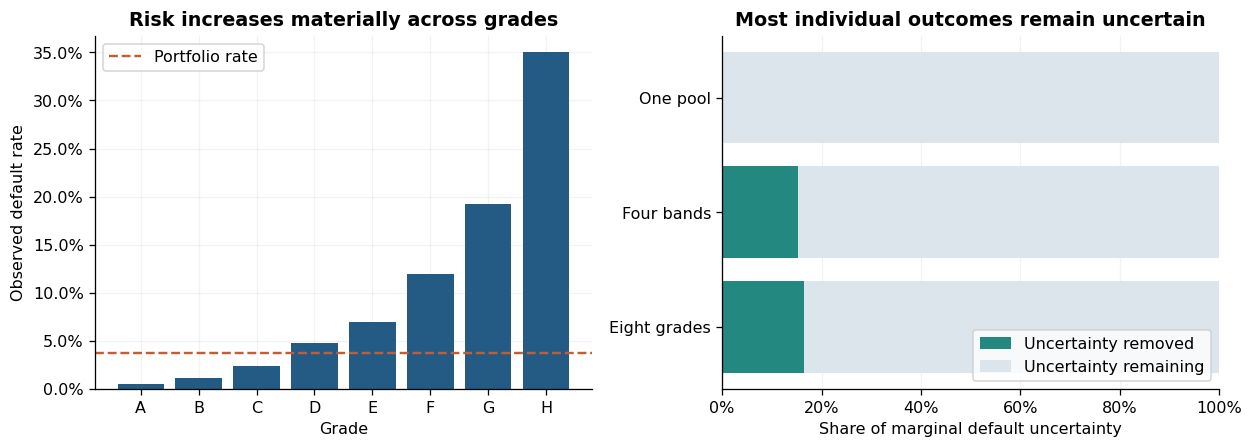

,entropy ratio
Eight grades,16.54%
Four bands,15.22%
One pool,0.00%


**Result.** Eight grades remove 16.5% of 0.160 nats of marginal uncertainty, despite AUC 0.810.

In [9]:
fine = pd_spec[["grade", "n", "defaults", "observed_rate"]].copy()
four = fine.assign(band=np.repeat(["AB", "CD", "EF", "GH"], 2)).groupby("band")[["n", "defaults"]].sum()
four["observed_rate"] = four.defaults / four.n
one = pd.DataFrame({"n": [fine.n.sum()], "observed_rate": [fine.defaults.sum() / fine.n.sum()]})
ratios = pd.Series({label: m.conditional_information_entropy_ratio(frame, "observed_rate", "n")
                    for label, frame in [("Eight grades", fine), ("Four bands", four), ("One pool", one)]})
prevalence = fine.defaults.sum() / fine.n.sum()
marginal_entropy = stats.entropy([prevalence, 1 - prevalence])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(GRADES, fine.observed_rate)
axes[0].axhline(prevalence, ls="--", color=ORANGE, label="Portfolio rate")
axes[0].set(title="Risk increases materially across grades", xlabel="Grade", ylabel="Observed default rate")
axes[0].legend(); percent(axes[0])
axes[1].barh(ratios.index, ratios, label="Uncertainty removed", color=TEAL)
axes[1].barh(ratios.index, 1 - ratios, left=ratios, label="Uncertainty remaining", color="#DCE5EC")
axes[1].set(title="Most individual outcomes remain uncertain", xlabel="Share of marginal default uncertainty", xlim=(0, 1))
axes[1].legend(loc="lower right"); percent(axes[1], "x")
finish(fig)
table(ratios.rename("entropy ratio").to_frame(), {"entropy ratio": "{:.2%}"})
report(f"Eight grades remove {ratios.iloc[0]:.1%} of {marginal_entropy:.3f} nats of marginal "
       f"uncertainty, despite AUC {m.roc_auc(pd_portfolio, 'default', 'pd'):.3f}.")

**What this shows.** Ranking improvement need not make individual outcomes predictable. Pooling grades discards information in this fixed empirical distribution. The inputs use observed rates, so splitting bins ever more finely on the same outcomes can also overstate information; define grades before evaluating them on a separate sample.

**Try changing:** which adjacent grades are pooled and recompute the pooled rates from total defaults and counts.

<a id="example-07"></a>
### 7. Mutual information — nats per observation, not evidence from sample size

**Question.** Does multiplying every grade count by ten multiply the information measure?

The historical name `kullback_leibler_dist` returns mutual information between grade and default, in nats. Compute each grade’s weighted Bernoulli KL contribution to the portfolio rate. Compare the original weights with ten times those weights while keeping rates fixed; this is a mathematical rescaling, not new observations.

[API, formula and statistical sources](../reference/kullback_leibler_dist.md).

,n,observed_rate,portfolio_share,information_nats
grade,,,,
A,2200,0.50%,27.50%,0.0063
B,1900,1.16%,23.75%,0.0030
C,1400,2.36%,17.50%,0.0005
D,1000,4.80%,12.50%,0.0002
E,700,7.00%,8.75%,0.0010
F,450,12.00%,5.62%,0.0034
G,250,19.20%,3.12%,0.0054
H,100,35.00%,1.25%,0.0066


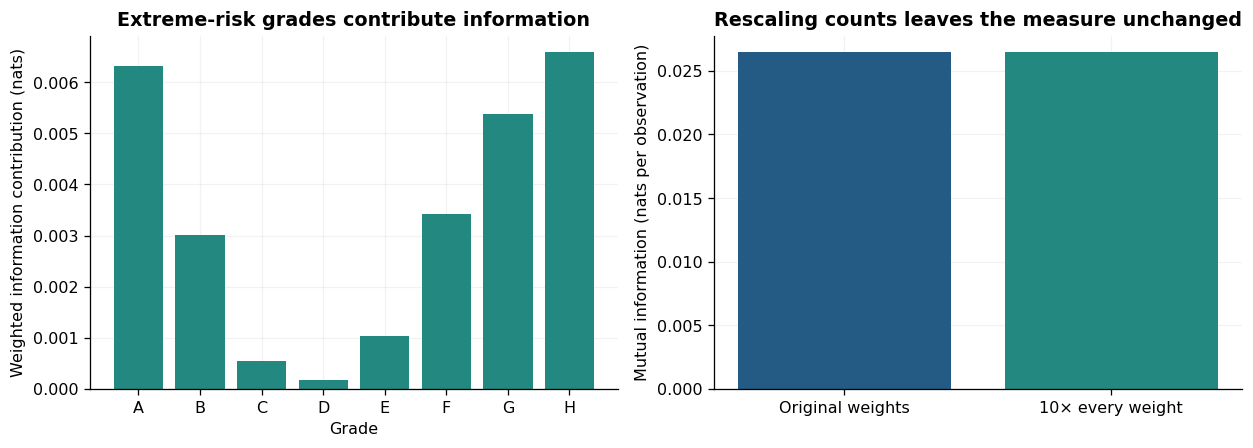

**Result.** Mutual information is 0.02645 nats with the original counts and 0.02645 after rescaling. The grade contributions sum to the same total.

In [10]:
data = pd_spec[["grade", "n", "observed_rate"]].copy()
p_bar = np.average(data.observed_rate, weights=data.n)
r = data.observed_rate.to_numpy()
data["portfolio_share"] = data.n / data.n.sum()
data["information_nats"] = data.portfolio_share * (
    special.rel_entr(r, p_bar) + special.rel_entr(1 - r, 1 - p_bar))
value = m.kullback_leibler_dist(data, "observed_rate", "n")
scaled = m.kullback_leibler_dist(data.assign(n=data.n * 10), "observed_rate", "n")
table(data.set_index("grade"), {"observed_rate": "{:.2%}", "portfolio_share": "{:.2%}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(GRADES, data.information_nats, color=TEAL)
axes[0].set(title="Extreme-risk grades contribute information", xlabel="Grade", ylabel="Weighted information contribution (nats)")
axes[1].bar(["Original weights", "10× every weight"], [value, scaled], color=[BLUE, TEAL])
axes[1].set(title="Rescaling counts leaves the measure unchanged", ylabel="Mutual information (nats per observation)")
finish(fig)
report(f"Mutual information is {value:.5f} nats with the original counts and {scaled:.5f} "
       "after rescaling. The grade contributions sum to the same total.")

**What this shows.** This is an average reduction in uncertainty, not a p-value or the total information in a sample. More independent observations would change precision, but multiplying weights changes neither the shares nor this descriptive statistic. Like IV, it does not encode the business ordering of grade labels.

**Try changing:** only the weight of H; changing the portfolio mixture, unlike rescaling every weight, changes the measure.

<a id="example-08"></a>
### 8. Cumulative LGD accuracy ratio — a perfect score can be misleading

**Question.** Can a predictor that assigns every facility the lowest loss grade beat a useful model?

Use the 600 completed defaults on five ordered loss bands: 0–20%, 20–40%, 40–60%, 60–80%, and 80–100%. Compare the varying model grades with a constant grade-1 predictor. Both predictions and outcomes use the same low-to-high scale.

[API, formula and statistical sources](../reference/cumulative_lgd_accuracy_ratio.md).

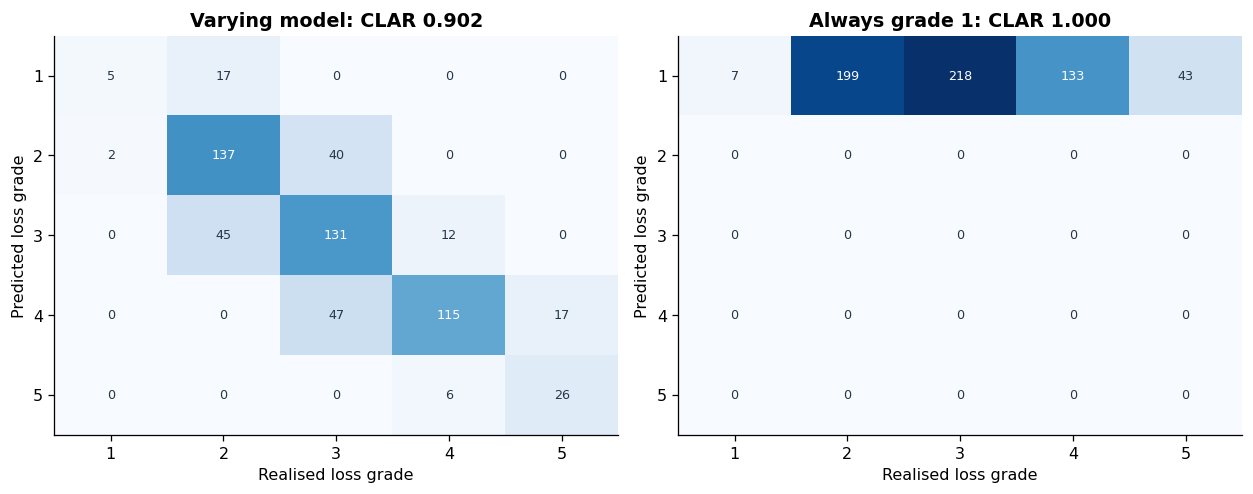

,CLAR
Varying model,0.9016
Always grade 1,1.0000


**Result.** The constant predictor attains CLAR 1.000, versus 0.902 for the varying model.

In [11]:
data = lgd.assign(constant_grade=1)
order = list(range(1, 6))
scores = {}
matrices = []
for label, column in [("Varying model", "pred_grade"), ("Always grade 1", "constant_grade")]:
    scores[label] = m.cumulative_lgd_accuracy_ratio(data, column, "real_grade", rating_order=order)
    matrices.append(pd.crosstab(data[column], data.real_grade).reindex(index=order, columns=order, fill_value=0))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (label, score), counts in zip(axes, scores.items(), matrices):
    heatmap(ax, counts, order, order, f"{label}: CLAR {score:.3f}", vmax=max(t.to_numpy().max() for t in matrices))
    ax.set(xlabel="Realised loss grade", ylabel="Predicted loss grade")
finish(fig)
table(pd.Series(scores, name="CLAR").to_frame())
report(f"The constant predictor attains CLAR {scores['Always grade 1']:.3f}, "
       f"versus {scores['Varying model']:.3f} for the varying model.")

**What this shows.** This convention integrates asymmetric threshold agreement; it is not a chance-adjusted ranking measure. Predictions that never exceed the realised grade attain the maximum. The constant predictor clearly cannot prioritise facilities. Inspect the cross-table and use a separate ranking assessment such as loss capture ratio or Somers’ D.

**Try changing:** `constant_grade` from 1 to 5 and explain the asymmetry before interpreting the new score.

<a id="example-09"></a>
### 9. Loss capture ratio — prioritise loss intensity, not just big accounts

**Question.** Which ordering captures the most realised loss for a fixed share of exposure reviewed?

Use all 600 facilities with heterogeneous EAD. Compare the predicted-LGD ordering with an exposure-only priority score and the hindsight ideal ordered by realised LGD. The horizontal axis is cumulative exposure, not the number of facilities. The exposure score is scaled into [0,1] solely to satisfy the API’s bounded input.

[API, formula and statistical sources](../reference/loss_capture_ratio.md).

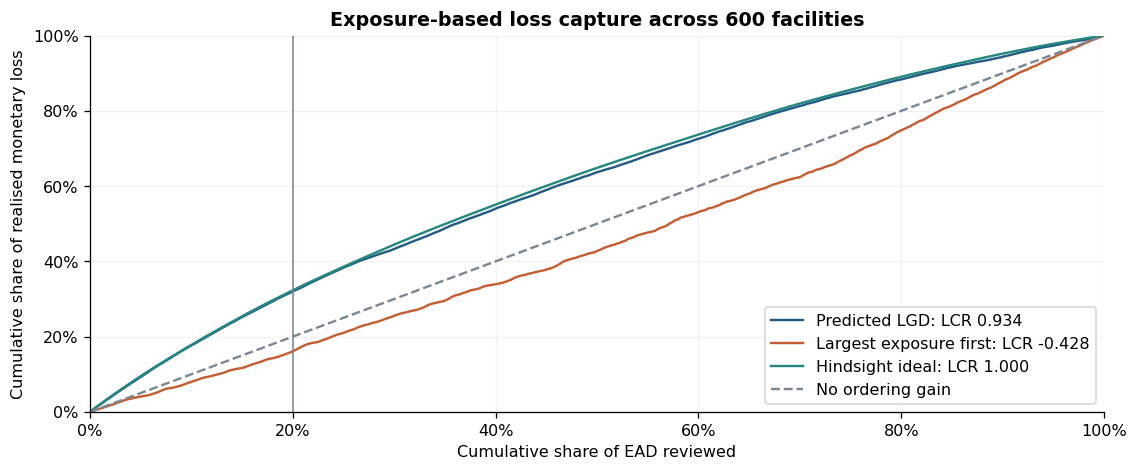

,LCR,loss at 20% EAD
ordering,,
Predicted LGD,0.9338,32.0%
Largest exposure first,-0.4284,16.1%
Hindsight ideal,1.0000,32.3%


**Result.** The predicted-LGD ordering captures 32.0% of loss at 20% of exposure. The ideal curve is available only after outcomes are known.

In [12]:
data = lgd.copy()
data["exposure_priority"] = data.ead.rank(pct=True)
summary = []
fig, ax = plt.subplots()
for label, column in [("Predicted LGD", "predicted"), ("Largest exposure first", "exposure_priority"),
                      ("Hindsight ideal", "realised")]:
    x, y = capture_curve(data, column)
    lcr = m.loss_capture_ratio(data.ead, data[column], data.realised)
    at_20 = np.interp(.2, x, y)
    ax.plot(x, y, label=f"{label}: LCR {lcr:.3f}")
    summary.append({"ordering": label, "LCR": lcr, "loss at 20% EAD": at_20})
ax.plot([0, 1], [0, 1], "--", color=GREY, label="No ordering gain")
ax.axvline(.2, color=GREY, lw=1)
ax.set(xlabel="Cumulative share of EAD reviewed", ylabel="Cumulative share of realised monetary loss",
       title="Exposure-based loss capture across 600 facilities", xlim=(0, 1), ylim=(0, 1))
percent(ax, "x"); percent(ax); ax.legend(loc="lower right")
finish(fig)
table(pd.DataFrame(summary).set_index("ordering"), {"loss at 20% EAD": "{:.1%}"})
report(f"The predicted-LGD ordering captures {summary[0]['loss at 20% EAD']:.1%} of loss "
       "at 20% of exposure. The ideal curve is available only after outcomes are known.")

**What this shows.** LCR compares area gains above the diagonal against the ideal gain. Large accounts can consume the exposure budget without capturing high loss intensity. The 20% figures interpolate along the curve and allow a fractional boundary band; they are not an integer-facility work queue. A constant score gives zero ordering gain.

**Try changing:** the review budget from 20% to 10% or 40%, or replace EAD with equal weights to see how the target changes.

<a id="calibration"></a>
## PD calibration

Inspect where forecasts fail, not only whether a portfolio-level statistic rejects.

<a id="example-10"></a>
### 10. Binomial test — locate underestimation across eight grades

**Question.** Which grades have more defaults than their forecast PD plausibly allows?

Use the main cohort with 100–2,200 obligors per grade. The null uses independent Bernoulli defaults with the fixed common grade PD; the alternative is a higher default rate. Plot the observed rate and the smallest integer default count that would reject at 5%, translated into a rate. Decisions are separate, unadjusted grade tests.

[API, formula and statistical sources](../reference/binomial_test.md).

,Predicted PD,Total count,Defaults,Actual Default Rate,p_value,Reject H0,First rejecting count
Rating class,,,,,,,
A,0.40%,2200,11.0000,0.50%,0.27,False,15
B,0.80%,1900,22.0000,1.16%,0.0586,False,23
C,1.50%,1400,33.0000,2.36%,0.00879,True,30
D,3.00%,1000,48.0000,4.80%,0.00125,True,40
E,5.50%,700,49.0000,7.00%,0.0526,False,50
F,9.50%,450,54.0000,12.00%,0.0455,True,54
G,16.00%,250,48.0000,19.20%,0.0998,False,51
H,26.00%,100,35.0000,35.00%,0.029,True,34


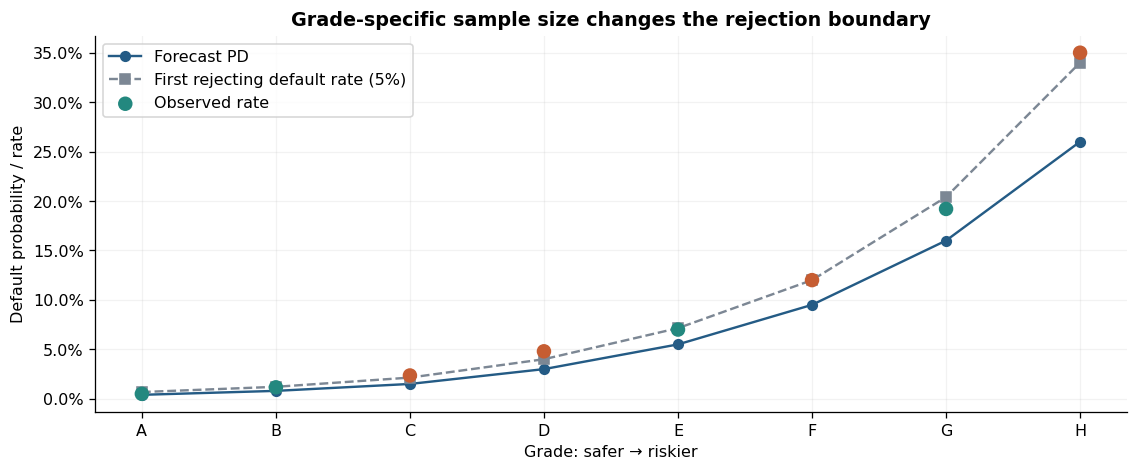

**Result.** Underestimation rejects at the unadjusted 5% level in grades C, D, F, H. Orange observations are at or above their grade's integer rejection boundary.

In [13]:
result = m.binomial_test(pd_portfolio, "grade", "default", "pd", alpha_level=.05)
# Reject when D exceeds the 95th binomial percentile; use an integer count boundary.
n, p = result["Total count"].to_numpy(), result["Predicted PD"].to_numpy()
critical_defaults = stats.binom.ppf(.95, n, p).astype(int) + 1
result["First rejecting count"] = critical_defaults
table(result.set_index("Rating class"), {"Predicted PD": "{:.2%}",
      "Actual Default Rate": "{:.2%}", "p_value": "{:.3g}"})
fig, ax = plt.subplots()
ax.plot(GRADES, p, "o-", label="Forecast PD")
ax.plot(GRADES, critical_defaults / n, "s--", color=GREY, label="First rejecting default rate (5%)")
ax.scatter(GRADES, result["Actual Default Rate"], s=65,
           c=np.where(result["Reject H0"], ORANGE, TEAL), zorder=3, label="Observed rate")
ax.set(title="Grade-specific sample size changes the rejection boundary",
       xlabel="Grade: safer → riskier", ylabel="Default probability / rate")
percent(ax); ax.legend(); finish(fig)
rejected = result.loc[result["Reject H0"], "Rating class"].tolist()
report(f"Underestimation rejects at the unadjusted 5% level in grades {', '.join(rejected)}. "
       "Orange observations are at or above their grade's integer rejection boundary.")

**What this shows.** An observed rate above PD is not by itself a rejection. Grade size and binomial discreteness matter, especially in the thin high-risk tail. Correlated obligors would invalidate the independent-binomial reference; heterogeneous individual PDs would require more than this common-PD grade calculation.

**Try changing:** a single grade’s count and default count in a copy of `pd_spec`, then expand it again; preserve the rate to isolate sample-size effects.

<a id="example-11"></a>
### 11. Jeffreys test — zero defaults does not mean zero risk

**Question.** How does uncertainty change when zero defaults are observed in 100, 500 or 2,000 accounts?

Construct six independent grade/cohort cells, including three AAA cohorts with the same 0.1% PD but different sample sizes. Jeffreys uses a Beta(½,½) prior. Its returned `p_value` is the posterior probability that the true rate is at or below the forecast PD, not a frequentist binomial p-value. The intervals below are central 90% posterior credible intervals; their upper endpoint is the 95th percentile.

[API, formula and statistical sources](../reference/jeffreys_test.md).

,Predicted PD,Total count,Defaults,Actual Default Rate,P(true PD ≤ forecast | data),Reject H0,Posterior mean,95% upper bound
Rating class,,,,,,,,
AAA / 100,0.10%,100,0.0000,0.00%,0.346,False,0.495%,1.898%
AAA / 500,0.10%,500,0.0000,0.00%,0.683,False,0.100%,0.383%
AAA / 2000,0.10%,2000,0.0000,0.00%,0.955,False,0.025%,0.096%
AA,0.40%,1200,7.0000,0.58%,0.155,False,0.624%,1.039%
A,0.90%,900,15.0000,1.67%,0.0129,True,1.720%,2.488%
BBB,2.50%,600,24.0000,4.00%,0.0137,True,4.077%,5.484%


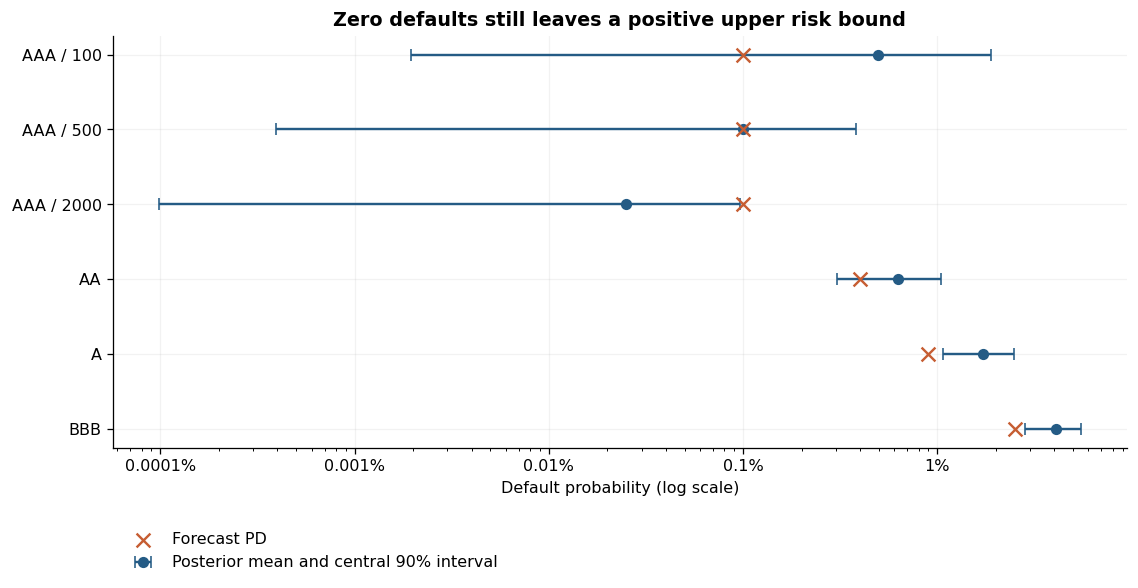

**Result.** With zero defaults, the 95% upper bound falls from 1.90% at n=100 to 0.10% at n=2,000. Neither is zero.

In [14]:
spec = pd.DataFrame({
    "grade": ["AAA / 100", "AAA / 500", "AAA / 2000", "AA", "A", "BBB"],
    "n": [100, 500, 2000, 1200, 900, 600],
    "defaults": [0, 0, 0, 7, 15, 24],
    "pd": [.001, .001, .001, .004, .009, .025],
})
data = expand_grades(spec, seed=11)
result = m.jeffreys_test(data, "grade", "default", "pd")
a, b = spec.defaults + .5, spec.n - spec.defaults + .5
mean = a / (a + b)
lower, upper = stats.beta.ppf(.05, a, b), stats.beta.ppf(.95, a, b)
result["Posterior mean"] = mean
result["95% upper bound"] = upper
shown = result.rename(columns={"p_value": "P(true PD ≤ forecast | data)"})
table(shown.set_index("Rating class"), {"Predicted PD": "{:.2%}", "Actual Default Rate": "{:.2%}",
      "Posterior mean": "{:.3%}", "95% upper bound": "{:.3%}",
      "P(true PD ≤ forecast | data)": "{:.3g}"})
fig, ax = plt.subplots(figsize=(10, 5.3))
positions = np.arange(len(spec))
ax.errorbar(mean, positions, xerr=[mean - lower, upper - mean], fmt="o", capsize=4,
             color=BLUE, label="Posterior mean and central 90% interval")
ax.scatter(spec.pd, positions, marker="x", s=75, color=ORANGE, label="Forecast PD", zorder=3)
ax.set(yticks=positions, yticklabels=spec.grade, xscale="log", xlabel="Default probability (log scale)",
       title="Zero defaults still leaves a positive upper risk bound")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{100 * value:g}%"))
ax.invert_yaxis()
ax.legend(loc="upper left", bbox_to_anchor=(0, -.17), frameon=False)
finish(fig)
report(f"With zero defaults, the 95% upper bound falls from {upper[0]:.2%} at n=100 "
       f"to {upper[2]:.2%} at n=2,000. Neither is zero.")

**What this shows.** The amount of information behind a zero matters. Small posterior mass below the forecast signals underestimation under the stated prior and sampling model. Do not describe a credible interval as a frequentist confidence interval or replace its endpoint with the observed zero rate.

**Try changing:** one of the zero-default counts to one; inspect how much the posterior moves at each cohort size.

<a id="example-12"></a>
### 12. Hosmer test — a correct portfolio total can hide wrong grades

**Question.** Can total expected defaults be exactly right while grade calibration is clearly wrong?

Create eight grades of 1,000 obligors. Externally fixed PDs imply at least ten expected defaults per grade. Add defaults to safer grades and remove the same number from riskier grades. The shifts sum to zero. With no parameters estimated from these outcomes, use the implementation’s fixed-grade convention `ddof=0` (eight chi-square degrees of freedom).

[API, formula and statistical sources](../reference/hosmer_test.md).

,n,pd,defaults,expected,observed_rate,chi2_contribution
grade,,,,,,
A,1000,1.0%,20,10.0000,2.0%,10.1010
B,1000,2.0%,35,20.0000,3.5%,11.4796
C,1000,3.5%,50,35.0000,5.0%,6.6617
D,1000,5.0%,70,50.0000,7.0%,8.4211
E,1000,8.0%,70,80.0000,7.0%,1.3587
F,1000,12.0%,105,120.0000,10.5%,2.1307
G,1000,18.0%,165,180.0000,16.5%,1.5244
H,1000,27.0%,250,270.0000,25.0%,2.0294


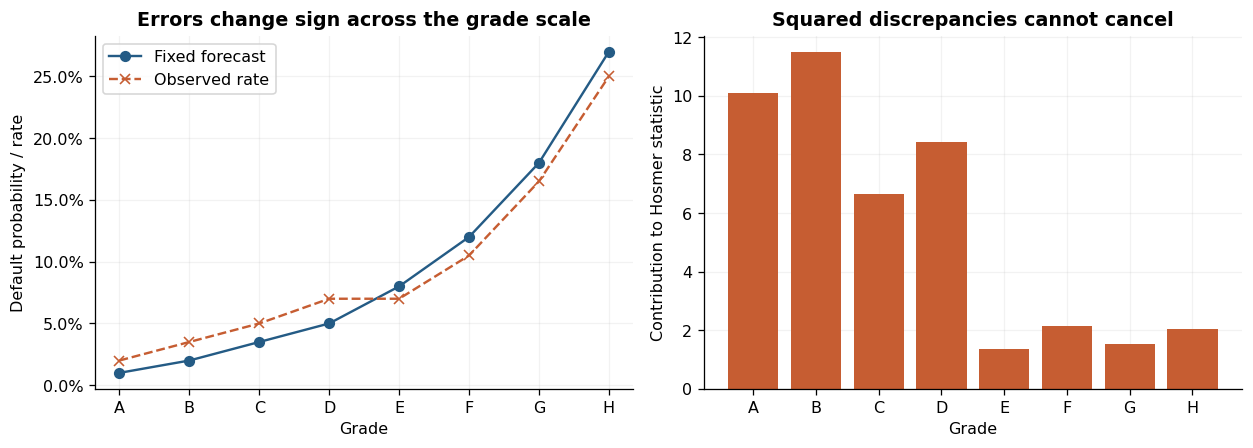

**Result.** Expected and observed defaults both total 765; nevertheless, χ² = 43.71, df = 8, p = 6.46e-07, reject = True.

In [15]:
spec = pd.DataFrame({"grade": GRADES, "n": [1000] * 8,
                     "pd": [.01, .02, .035, .05, .08, .12, .18, .27]})
shifts = np.array([10, 15, 15, 20, -10, -15, -15, -20])
spec["defaults"] = np.rint(spec.n * spec.pd).astype(int) + shifts
data = expand_grades(spec, seed=12)
p_value, reject = m.hosmer_test(data, "grade", "default", "pd", ddof=0)
spec["expected"] = spec.n * spec.pd
spec["observed_rate"] = spec.defaults / spec.n
spec["chi2_contribution"] = (spec.defaults - spec.expected) ** 2 / (spec.expected * (1 - spec.pd))
table(spec.set_index("grade"), {"pd": "{:.1%}", "observed_rate": "{:.1%}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(GRADES, spec.pd, "o-", label="Fixed forecast")
axes[0].plot(GRADES, spec.observed_rate, "x--", color=ORANGE, label="Observed rate")
axes[0].set(title="Errors change sign across the grade scale", xlabel="Grade", ylabel="Default probability / rate")
axes[0].legend(); percent(axes[0])
axes[1].bar(GRADES, spec.chi2_contribution, color=ORANGE)
axes[1].set(title="Squared discrepancies cannot cancel", xlabel="Grade", ylabel="Contribution to Hosmer statistic")
finish(fig)
report(f"Expected and observed defaults both total {spec.defaults.sum():,}; nevertheless, "
       f"χ² = {spec.chi2_contribution.sum():.2f}, df = 8, p = {p_value:.3g}, reject = {reject}.")

**What this shows.** An accurate aggregate default count is compatible with substantial errors in individual grades. Hosmer squares the grade discrepancies before summing. Its reference distribution relies on suitable expected counts and independent defaults. Do not automatically subtract two degrees of freedom: fitted-model versions need a justification appropriate to their estimation and grouping procedure.

**Try changing:** `shifts` while keeping its sum zero; move a fixed number of excess defaults between low-PD and high-PD grades.

<a id="example-13"></a>
### 13. Spiegelhalter — a weighted moment can cancel

**Question.** Can a calibration test return z = 0 despite obvious grade-level errors?

In a separate 8,000-obligor case, increase defaults in grade B by 25 and decrease them in H by 60. Spiegelhalter weights errors by (1−2PD): 25 × 0.96 and −60 × 0.40 cancel exactly. All other grades equal their expected counts. This is a constructed demonstration of what the statistic sees.

[API, formula and statistical sources](../reference/spiegelhalter_test.md).

,n,pd,defaults,observed_rate,weighted_error
grade,,,,,
A,1000,1.0%,10,1.0%,0.0000
B,1000,2.0%,45,4.5%,24.0000
C,1000,4.0%,40,4.0%,0.0000
D,1000,6.0%,60,6.0%,0.0000
E,1000,10.0%,100,10.0%,0.0000
F,1000,15.0%,150,15.0%,0.0000
G,1000,20.0%,200,20.0%,0.0000
H,1000,30.0%,240,24.0%,-24.0000


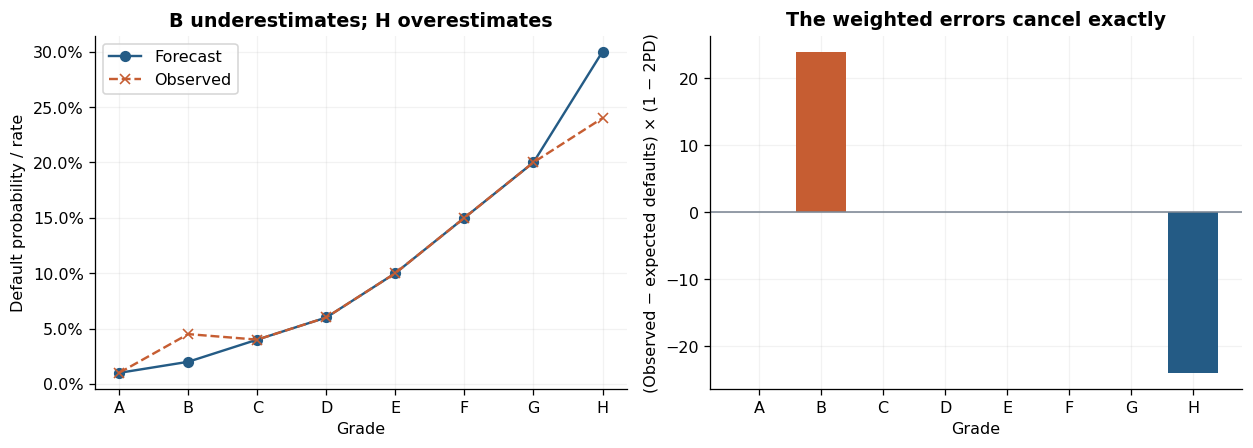

**Result.** Spiegelhalter z = -0.000, two-sided p = 1.000, reject = False; Hosmer p = 6.27e-08 on the same observations.

In [16]:
spec = pd.DataFrame({"grade": GRADES, "n": [1000] * 8,
                     "pd": [.01, .02, .04, .06, .10, .15, .20, .30]})
shifts = np.array([0, 25, 0, 0, 0, 0, 0, -60])
spec["defaults"] = np.rint(spec.n * spec.pd).astype(int) + shifts
data = expand_grades(spec, seed=13)
z, reject = m.spiegelhalter_test(data, "grade", "default", "pd")
hosmer_p, _ = m.hosmer_test(data, "grade", "default", "pd", ddof=0)
spec["observed_rate"] = spec.defaults / spec.n
spec["weighted_error"] = shifts * (1 - 2 * spec.pd)
table(spec.set_index("grade"), {"pd": "{:.1%}", "observed_rate": "{:.1%}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(GRADES, spec.pd, "o-", label="Forecast")
axes[0].plot(GRADES, spec.observed_rate, "x--", label="Observed")
axes[0].set(title="B underestimates; H overestimates", xlabel="Grade", ylabel="Default probability / rate")
axes[0].legend(); percent(axes[0])
axes[1].bar(GRADES, spec.weighted_error, color=[ORANGE if x > 0 else BLUE for x in spec.weighted_error])
axes[1].axhline(0, color=GREY, lw=1)
axes[1].set(title="The weighted errors cancel exactly", xlabel="Grade", ylabel="(Observed − expected defaults) × (1 − 2PD)")
finish(fig)
report(f"Spiegelhalter z = {z:.3f}, two-sided p = {2 * stats.norm.sf(abs(z)):.3f}, "
       f"reject = {reject}; Hosmer p = {hosmer_p:.3g} on the same observations.")

**What this shows.** Spiegelhalter tests one weighted calibration moment. Passing that check does not establish calibration at every PD level. A grade plot or grouped test exposes the opposing discrepancies here. The two-sided normal reference is an approximation for independent outcomes with fixed forecasts.

**Try changing:** the H shift from −60 to −40, then observe which part of the cancellation breaks.

<a id="example-14"></a>
### 14. Brier score — judge probabilities against a useful baseline

**Question.** Is a numerically small Brier score impressive in a portfolio with few defaults?

Compare four fixed forecasts on the same 8,000 obligors: the original grade PDs, their 50% uplift, a flat 3.5% portfolio forecast, and zero for every account. The flat forecast is a specified benchmark, not the default rate estimated from this validation set. Split the score into contributions from survivors and defaults.

[API, formula and statistical sources](../reference/brier_score.md).

,Brier,AUC,survivor contribution,default contribution,skill vs flat
forecast,,,,,
Original,0.0334,0.8099,0.0021,0.0313,+7.5%
50% uplift,0.0333,0.8099,0.0046,0.0287,+7.8%
Flat 3.5%,0.0361,0.5000,0.0012,0.0349,+0.0%
Always zero,0.0375,0.5000,0.0000,0.0375,-3.9%


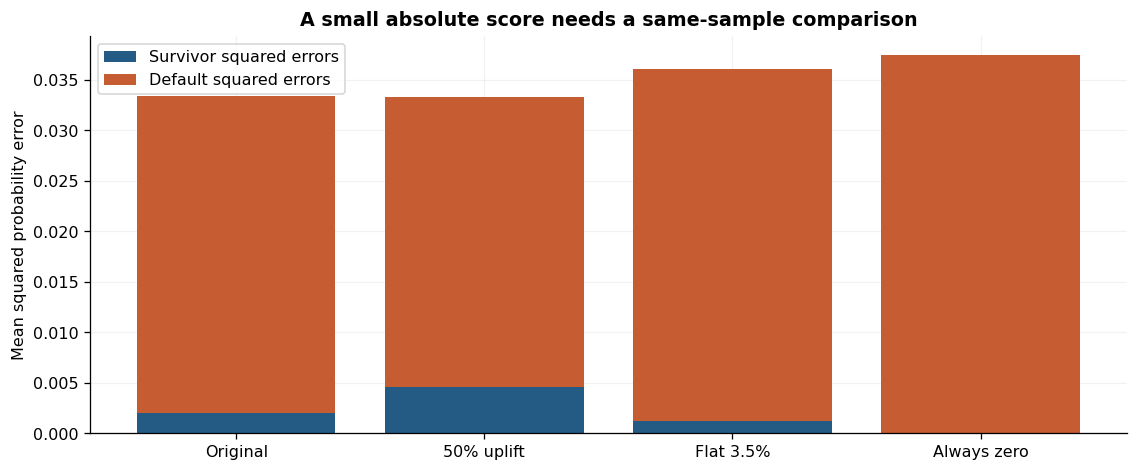

**Result.** Always predicting zero scores 0.0375, exactly the 3.75% default rate. The uplift changes Brier from 0.0334 to 0.0333 while AUC is unchanged.

In [17]:
data = pd_portfolio.assign(flat_pd=.035, zero_pd=0.0)
rows = []
for label, column in [("Original", "pd"), ("50% uplift", "pd_uplift"),
                      ("Flat 3.5%", "flat_pd"), ("Always zero", "zero_pd")]:
    squared = (data.default - data[column]) ** 2
    rows.append({"forecast": label, "Brier": m.brier_score(data, "grade", "default", column),
                 "AUC": m.roc_auc(data, "default", column),
                 "survivor contribution": squared[data.default == 0].sum() / len(data),
                 "default contribution": squared[data.default == 1].sum() / len(data)})
scores = pd.DataFrame(rows).set_index("forecast")
scores["skill vs flat"] = 1 - scores.Brier / scores.loc["Flat 3.5%", "Brier"]
table(scores, {"skill vs flat": "{:+.1%}"})
fig, ax = plt.subplots()
ax.bar(scores.index, scores["survivor contribution"], label="Survivor squared errors", color=BLUE)
ax.bar(scores.index, scores["default contribution"], bottom=scores["survivor contribution"],
       label="Default squared errors", color=ORANGE)
ax.set(title="A small absolute score needs a same-sample comparison", ylabel="Mean squared probability error")
ax.legend(); finish(fig)
report(f"Always predicting zero scores {scores.loc['Always zero', 'Brier']:.4f}, exactly the "
       f"{data.default.mean():.2%} default rate. The uplift changes Brier from "
       f"{scores.loc['Original', 'Brier']:.4f} to {scores.loc['50% uplift', 'Brier']:.4f} while AUC is unchanged.")

**What this shows.** Brier is a proper probability scoring rule that reflects both calibration and discrimination. Lower is better on the same target and observations. Its raw scale depends on prevalence; a low number alone is not a quality threshold. The stacked bars are contributions divided by the full sample size, not class-conditional means.

**Try changing:** the uplift factor or the fixed benchmark PD; compare improvement in Brier with the unchanged ordering.

<a id="example-15"></a>
### 15. Redelmeier — compare paired forecasts and state the null

**Question.** Is the Brier improvement from a PD uplift large relative to this comparison’s reference variance?

Use paired forecasts for all 8,000 obligors. The first forecast is the original PD and the second is the 50% uplift. Positive first-minus-second squared loss favours the uplift. Meliora’s Redelmeier-style normal test assumes independent Bernoulli outcomes whose true PD is the midpoint of the two fixed forecasts under the null.

[API, formula and statistical sources](../reference/redelmeier_test.md).

,n,mean_loss_difference,sum_loss_difference,portfolio_contribution
grade,,,,
A,2200,-0.0000,-0.0000,-0.0000
B,1900,0.0000,0.0240,0.0000
C,1400,0.0001,0.1012,0.0000
D,1000,0.0003,0.3150,0.0000
E,700,0.0001,0.0481,0.0000
F,450,0.0001,0.0534,0.0000
G,250,-0.0013,-0.3200,-0.0000
H,100,0.0065,0.6500,0.0001


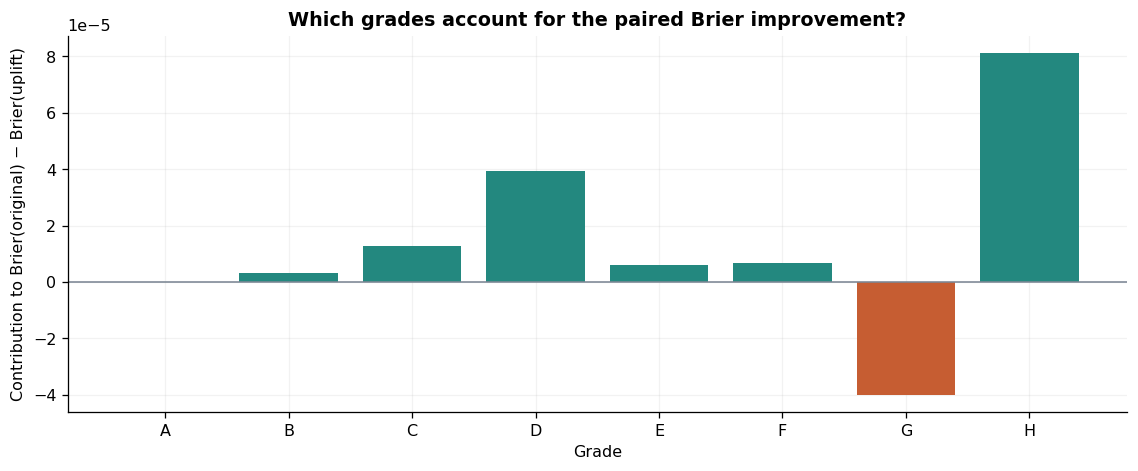

**Result.** Mean paired Brier improvement is 0.000109; z = 0.495, two-sided p = 0.621. Swapping forecasts gives z = -0.495 and the same p = 0.621.

In [18]:
data = pd_portfolio.copy()
z, p_value = m.redelmeier_test(data, default_flag="default", first_pd="pd", second_pd="pd_uplift")
reverse_z, reverse_p = m.redelmeier_test(data, default_flag="default", first_pd="pd_uplift", second_pd="pd")
data["loss_difference"] = (data.default - data.pd) ** 2 - (data.default - data.pd_uplift) ** 2
contributions = data.groupby("grade").agg(n=("default", "size"),
    mean_loss_difference=("loss_difference", "mean"), sum_loss_difference=("loss_difference", "sum"))
contributions["portfolio_contribution"] = contributions.sum_loss_difference / len(data)
table(contributions)
fig, ax = plt.subplots()
ax.bar(GRADES, contributions.portfolio_contribution,
       color=[TEAL if value > 0 else ORANGE for value in contributions.portfolio_contribution])
ax.axhline(0, color=GREY, lw=1)
ax.set(title="Which grades account for the paired Brier improvement?", xlabel="Grade",
       ylabel="Contribution to Brier(original) − Brier(uplift)")
finish(fig)
report(f"Mean paired Brier improvement is {data.loss_difference.mean():.6f}; z = {z:.3f}, "
       f"two-sided p = {p_value:.3g}. Swapping forecasts gives z = {reverse_z:.3f} "
       f"and the same p = {reverse_p:.3g}.")

**What this shows.** The small observed improvement does not reject the midpoint null at 5% in this case. The statistic preserves pairing, and its sign tells you which forecast benefits. The midpoint-Bernoulli null is stronger than unrestricted equality of average Brier scores. Interpret the p-value under that model; it is not a universal test that the challenger is superior. Forecasts and any uplift should be specified before evaluation on new outcomes.

**Try changing:** the second forecast to `pd` itself: identical forecasts return z = 0 and p = 1, with no comparative evidence.

<a id="example-16"></a>
### 16. Normal test — 24 years, not hundreds of thousands of independent trials

**Question.** Is there a persistent average annual underprediction after allowing for year-to-year variation?

Generate 24 synthetic annual cohorts from 2002–2025, with changing portfolio sizes and a time-varying predicted rate. Add independent random annual residuals with a small positive mean, then round to integer default counts. Each year is one observation in this test, irrespective of its number of obligors.

[API, formula and statistical sources](../reference/normal_test.md).

,obligors,defaults,predicted,realised,error
year,,,,,
2002,6000,112,1.80%,1.87%,+0.07%
2003,6783,161,1.93%,2.37%,+0.44%
2004,7565,197,2.05%,2.60%,+0.56%
2005,8348,225,2.14%,2.70%,+0.56%
2006,9130,272,2.19%,2.98%,+0.79%
2007,9913,231,2.20%,2.33%,+0.13%
2008,10696,276,2.16%,2.58%,+0.42%
2009,11478,256,2.09%,2.23%,+0.14%
2010,12261,221,1.98%,1.80%,-0.18%


,mean annual error,normal z,p_value,reject at 5%
0,+0.261%,4.6815,1.42e-06,True


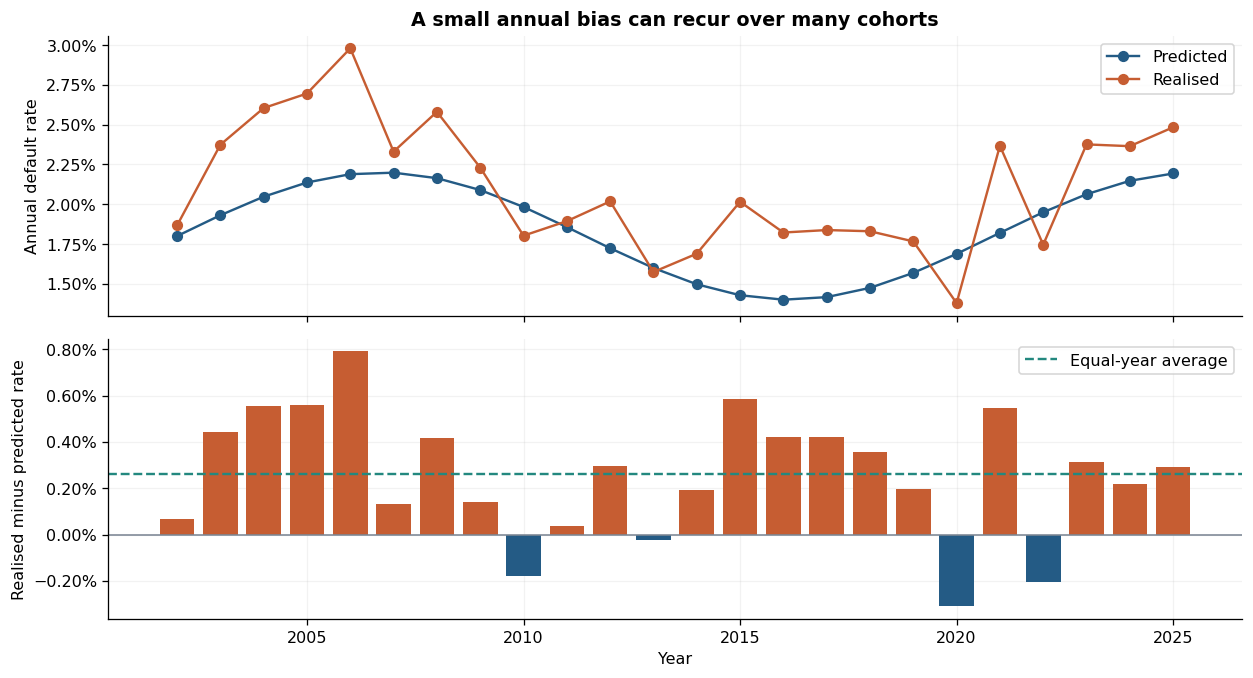

**Result.** There are 24 annual errors across 360,000 obligor-years. Equal-year bias is +0.261%; weighting years by obligor count would instead give +0.239%.

In [19]:
rng = np.random.default_rng(16)
years = np.arange(2002, 2026)
n = np.round(np.linspace(6000, 24000, len(years))).astype(int)
predicted = .018 + .004 * np.sin(np.arange(len(years)) / 3)
annual_error = rng.normal(.0025, .003, len(years))
defaults = np.rint(n * (predicted + annual_error)).astype(int)
annual = pd.DataFrame({"year": years, "obligors": n, "defaults": defaults,
                       "predicted": predicted, "realised": defaults / n})
annual["error"] = annual.realised - annual.predicted
result = m.normal_test(annual.predicted, annual.realised)
table(annual.set_index("year"), {"predicted": "{:.2%}", "realised": "{:.2%}", "error": "{:+.2%}"})
table(result.rename(columns={"estimate": "mean annual error", "t_stat": "normal z", "outcome": "reject at 5%"}),
      {"mean annual error": "{:+.3%}", "p_value": "{:.3g}"})
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(years, annual.predicted, "o-", label="Predicted")
axes[0].plot(years, annual.realised, "o-", label="Realised")
axes[0].set(title="A small annual bias can recur over many cohorts", ylabel="Annual default rate")
axes[0].legend(); percent(axes[0])
axes[1].bar(years, annual.error, color=np.where(annual.error > 0, ORANGE, BLUE))
axes[1].axhline(0, color=GREY, lw=1)
axes[1].axhline(annual.error.mean(), color=TEAL, ls="--", label="Equal-year average")
axes[1].set(xlabel="Year", ylabel="Realised minus predicted rate")
percent(axes[1]); axes[1].legend(); finish(fig)
report(f"There are {len(annual)} annual errors across {annual.obligors.sum():,} obligor-years. "
       f"Equal-year bias is {annual.error.mean():+.3%}; weighting years by obligor count "
       f"would instead give {np.average(annual.error, weights=annual.obligors):+.3%}.")

**What this shows.** The API’s `t_stat` column holds a statistic evaluated against a one-sided normal reference, not a Student t distribution. Twenty-four years provide more context than four but do not guarantee the approximation: serial dependence, overlapping horizons and shared shocks can make the reported tail too optimistic. Obligor-weighting would answer a different question from the average annual error.

**Try changing:** the annual error mean to zero, or add a multi-year common shock and examine why the independence assumption matters.

<a id="association"></a>
## LGD association

Rank agreement, linear association and numerical accuracy answer different questions.

<a id="example-17"></a>
### 17. Kendall’s tau — ties are part of the evidence

**Question.** How much does a five-grade scale change the number of usable ranking distinctions?

Use predicted and realised loss grades for 600 facilities. Count concordant, discordant and tied unordered pairs, then compare the unadjusted pair proportion tau-a with Meliora’s default tau-b. Tau-a below is a diagnostic calculation, not a second Meliora API or a separate significance test.

[API, formula and statistical sources](../reference/kendall_tau.md).

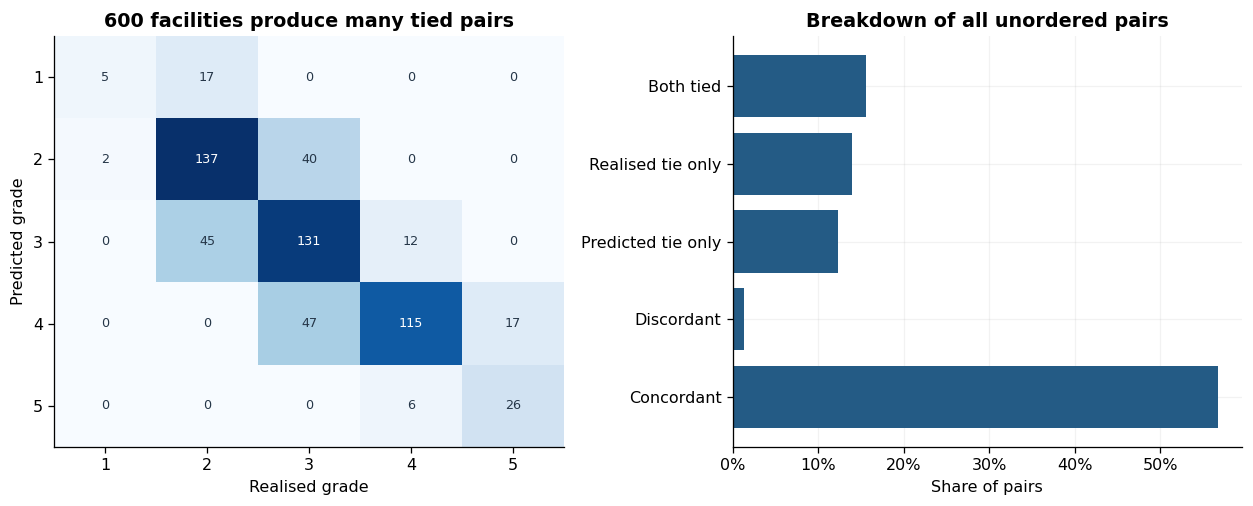

,pairs
Concordant,101903
Discordant,2500
Predicted tie only,22241
Realised tie only,25130
Both tied,27926


**Result.** Among 179,700 pairs, tau-a = 0.553; tie-adjusted tau-b = 0.776, with the returned two-sided p = 6.41e-110.

In [20]:
data = lgd[["pred_grade", "real_grade"]].copy()
tau, p_value = m.kendall_tau(data.pred_grade, data.real_grade, variant="b")
i, j = np.triu_indices(len(data), k=1)
dx = data.pred_grade.to_numpy()[i] - data.pred_grade.to_numpy()[j]
dy = data.real_grade.to_numpy()[i] - data.real_grade.to_numpy()[j]
counts = pd.Series({"Concordant": np.sum(dx * dy > 0), "Discordant": np.sum(dx * dy < 0),
                    "Predicted tie only": np.sum((dx == 0) & (dy != 0)),
                    "Realised tie only": np.sum((dx != 0) & (dy == 0)),
                    "Both tied": np.sum((dx == 0) & (dy == 0))})
tau_a = (counts.Concordant - counts.Discordant) / len(i)
cross = pd.crosstab(data.pred_grade, data.real_grade).reindex(index=range(1, 6), columns=range(1, 6), fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
heatmap(axes[0], cross, range(1, 6), range(1, 6), "600 facilities produce many tied pairs")
axes[0].set(xlabel="Realised grade", ylabel="Predicted grade")
axes[1].barh(counts.index, counts / counts.sum())
axes[1].set(title="Breakdown of all unordered pairs", xlabel="Share of pairs")
percent(axes[1], "x"); finish(fig)
table(counts.rename("pairs").to_frame())
report(f"Among {len(i):,} pairs, tau-a = {tau_a:.3f}; tie-adjusted tau-b = {tau:.3f}, "
       f"with the returned two-sided p = {p_value:.3g}.")

**What this shows.** Pairs tied on a rating scale carry different information from reversals. Tau-b adjusts its denominator for ties in both variables, making the scale convention material. A small p-value concerns zero association under independent facility observations; the much larger number of derived pairs is not an independent sample size.

**Try changing:** the grade boundaries when deriving the two grade columns from LGD; inspect the tie counts as well as tau.

<a id="example-18"></a>
### 18. Somers’ D — the conditioning direction matters

**Question.** Does the reported association change when predictions and outcomes swap roles?

Keep five predicted loss grades but report realised loss in three severity bands (below 35%, 35–65%, and at least 65%). The resulting 5 × 3 count table contains all 600 facilities. Rows are predictions, columns are realised outcomes; Somers’ D measures the second variable conditional on the first.

[API, formula and statistical sources](../reference/somersd.md).

severity,1,2,3
pred_grade,,,
1,22,0,0
2,93,86,0
3,15,168,5
4,0,82,97
5,0,0,32


,Somers D,p_value
direction,,
Realised | predicted,0.6434,1.05e-201
Predicted | realised,0.7853,1.05e-201


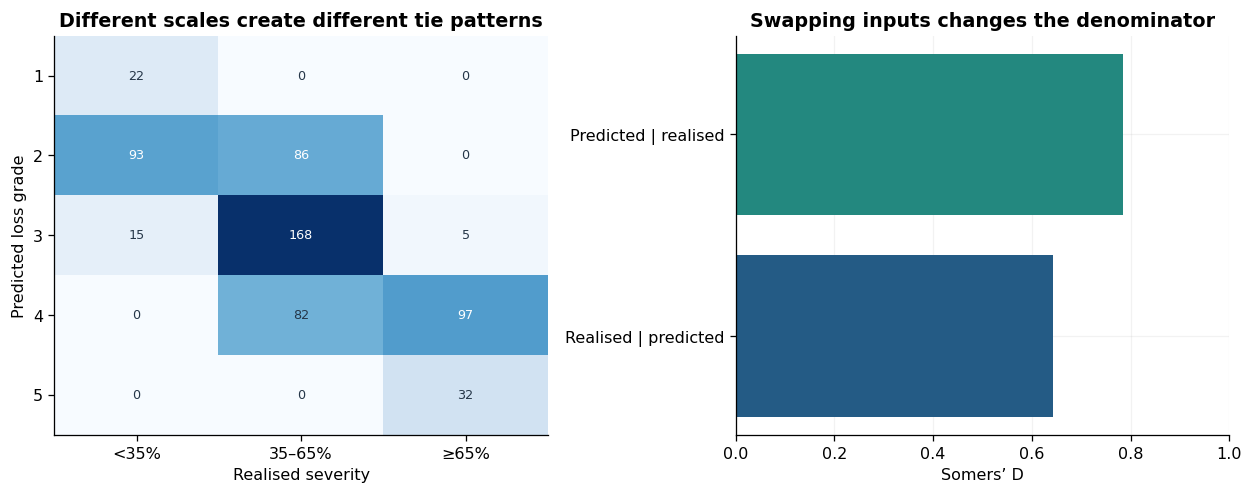

**Result.** D(realised | predicted) = 0.643; D(predicted | realised) = 0.785.

In [21]:
data = lgd.copy()
data["severity"] = np.digitize(data.realised, [.35, .65]) + 1
cross = pd.crosstab(data.pred_grade, data.severity).reindex(index=range(1, 6), columns=range(1, 4), fill_value=0)
forward = m.somersd(cross.to_numpy())
reverse = m.somersd(cross.to_numpy().T)
values = pd.DataFrame({"direction": ["Realised | predicted", "Predicted | realised"],
                       "Somers D": [forward.statistic, reverse.statistic],
                       "p_value": [forward.pvalue, reverse.pvalue]})
table(cross, caption="Input counts: predicted grades in rows, realised severity in columns")
table(values.set_index("direction"), {"p_value": "{:.3g}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
heatmap(axes[0], cross, range(1, 6), ["<35%", "35–65%", "≥65%"], "Different scales create different tie patterns")
axes[0].set(xlabel="Realised severity", ylabel="Predicted loss grade")
axes[1].barh(values.direction, values["Somers D"], color=[BLUE, TEAL])
axes[1].set(xlim=(0, 1), xlabel="Somers’ D", title="Swapping inputs changes the denominator")
finish(fig)
report(f"D(realised | predicted) = {forward.statistic:.3f}; "
       f"D(predicted | realised) = {reverse.statistic:.3f}.")

**What this shows.** Somers’ D conditions on pairs distinguished by the first variable, so it is asymmetric when the tie structures differ. Report the direction with the number and preserve the business ordering when passing a count table. Transposing the table changes the question; it is not a harmless presentation change.

**Try changing:** the realised severity cut points to create a more concentrated middle band and inspect both directions.

<a id="example-19"></a>
### 19. Spearman’s rho — strong ranks can coexist with a curved calibration error

**Question.** Can a forecast be almost perfectly ranked while its numerical values are systematically wrong?

Generate 600 forecasts spread over 5–95% and realised losses around the pre-specified nonlinear curve 0.05 + 0.8 × forecast³. The curve is a known synthetic mechanism, not one fitted to these outcomes. Compare original forecasts with values transformed by that same increasing function.

[API, formula and statistical sources](../reference/spearman_correlation.md).

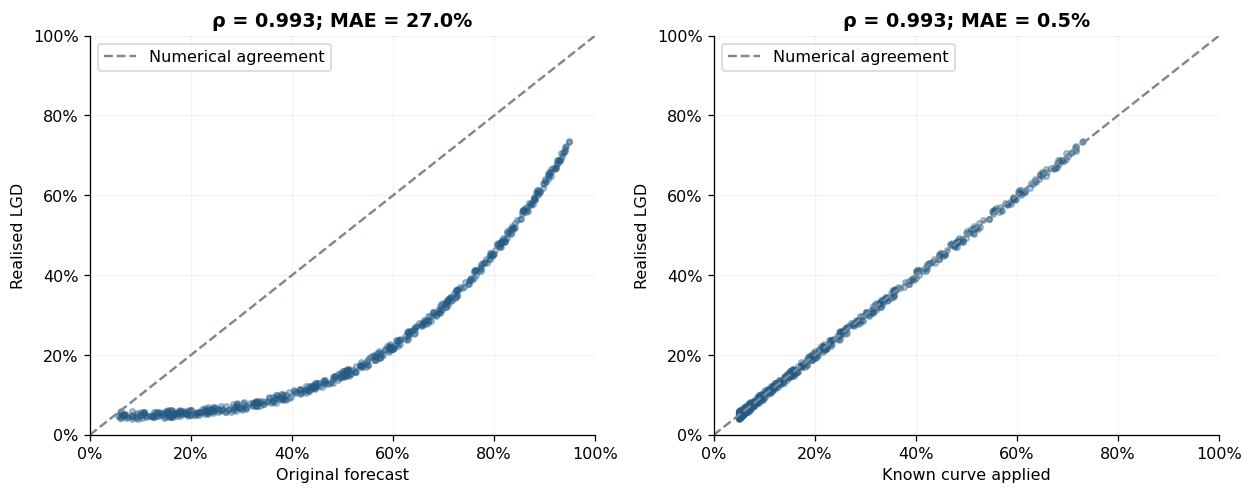

,Spearman rho,p_value,mean absolute error
forecast,,,
Original forecast,0.9929,0,27.05%
Known curve applied,0.9929,0,0.50%


**Result.** The increasing transformation preserves Spearman’s rho exactly, but sharply reduces numerical error.

In [22]:
rng = np.random.default_rng(19)
predicted = rng.uniform(.05, .95, 600)
transformed = .05 + .8 * predicted ** 3
realised = transformed + rng.uniform(-.01, .01, 600)
data = pd.DataFrame({"predicted": predicted, "transformed": transformed, "realised": realised})
rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, label, column in zip(axes, ["Original forecast", "Known curve applied"], ["predicted", "transformed"]):
    result = m.spearman_correlation(data[column], data.realised)
    mae = np.mean(np.abs(data[column] - data.realised))
    rows.append({"forecast": label, "Spearman rho": result.statistic,
                 "p_value": result.pvalue, "mean absolute error": mae})
    ax.scatter(data[column], data.realised, s=12, alpha=.35)
    ax.plot([0, 1], [0, 1], "--", color=GREY, label="Numerical agreement")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel=label, ylabel="Realised LGD",
           title=f"ρ = {result.statistic:.3f}; MAE = {mae:.1%}")
    percent(ax, "x"); percent(ax); ax.legend(loc="upper left")
finish(fig)
table(pd.DataFrame(rows).set_index("forecast"), {"mean absolute error": "{:.2%}", "p_value": "{:.3g}"})
report("The increasing transformation preserves Spearman’s rho exactly, but sharply reduces numerical error.")

**What this shows.** Spearman sees rank order, not the distance from the identity line. A high rho cannot establish LGD calibration. The displayed p-value uses SciPy’s approximate reference; an extremely small value can underflow to zero in numerical output and should be read as below numerical resolution, not literally impossible.

**Try changing:** the exponent from 3 to 2, or increase the outcome noise; separate a scale change from a loss of rank information.

<a id="example-20"></a>
### 20. Pearson’s r — a few extreme facilities can drive the headline

**Question.** Is a strong linear correlation representative of the bulk of the portfolio?

Construct 592 facilities in a narrow central LGD range with unrelated forecast and outcome fluctuations. Add eight legitimate tail observations with closely aligned low or high values. Compare the full sample with the central group to diagnose influence; excluding tails is not proposed as a model-selection rule.

[API, formula and statistical sources](../reference/pearson_correlation.md).

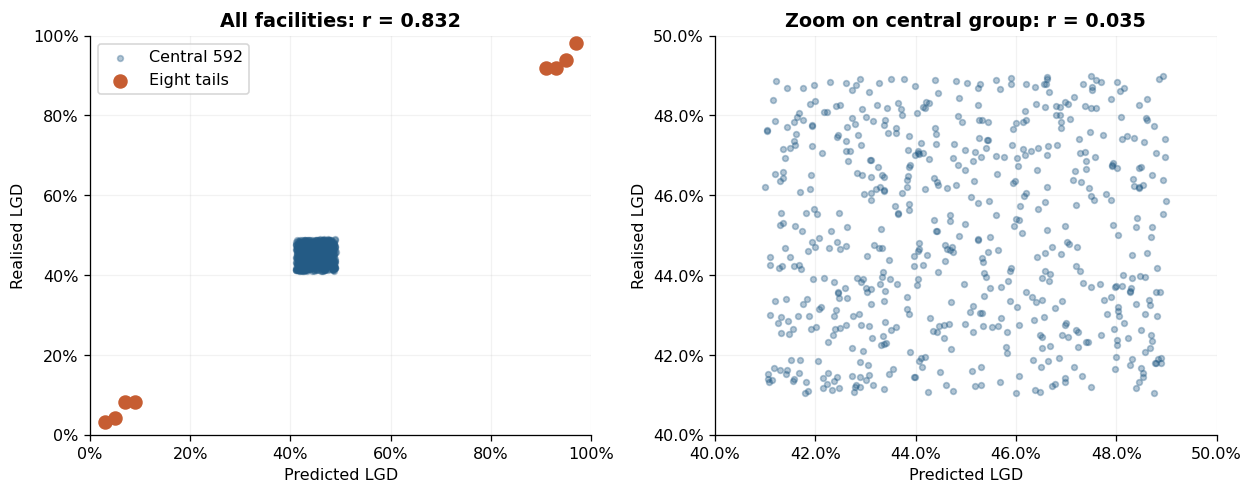

,n,Pearson r,p_value
sample,,,
All 600,600,0.8317,6.58e-155
Central 592,592,0.0352,0.393


**Result.** Eight of 600 facilities move r from 0.035 to 0.832.

In [23]:
rng = np.random.default_rng(20)
central = pd.DataFrame({"predicted": .45 + rng.uniform(-.04, .04, 592),
                        "realised": .45 + rng.uniform(-.04, .04, 592), "group": "Central 592"})
tail_pred = np.array([.03, .05, .07, .09, .91, .93, .95, .97])
tails = pd.DataFrame({"predicted": tail_pred, "realised": tail_pred + rng.uniform(-.015, .015, 8),
                      "group": "Eight tail facilities"})
data = pd.concat([central, tails], ignore_index=True)
rows = []
for label, sample in [("All 600", data), ("Central 592", central)]:
    result = m.pearson_correlation(sample.predicted, sample.realised)
    rows.append({"sample": label, "n": len(sample), "Pearson r": result.statistic, "p_value": result.pvalue})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(central.predicted, central.realised, s=13, alpha=.35, label="Central 592")
axes[0].scatter(tails.predicted, tails.realised, s=65, color=ORANGE, label="Eight tails")
axes[0].set(xlim=(0, 1), ylim=(0, 1), title=f"All facilities: r = {rows[0]['Pearson r']:.3f}")
axes[0].legend()
axes[1].scatter(central.predicted, central.realised, s=13, alpha=.35)
axes[1].set(xlim=(.4, .5), ylim=(.4, .5), title=f"Zoom on central group: r = {rows[1]['Pearson r']:.3f}")
for ax in axes:
    ax.set(xlabel="Predicted LGD", ylabel="Realised LGD"); percent(ax, "x"); percent(ax)
finish(fig)
table(pd.DataFrame(rows).set_index("sample"), {"p_value": "{:.3g}"})
report(f"Eight of 600 facilities move r from {rows[1]['Pearson r']:.3f} to {rows[0]['Pearson r']:.3f}.")

**What this shows.** Pearson correlation depends on numerical spread and influential points. Inspect the scatterplot, segment composition and sensitivity before generalising a headline coefficient. The conventional exact Pearson p-value assumes independent bivariate-normal observations under its null; this intentionally mixed synthetic population is an influence illustration, not support for that distributional assumption.

**Try changing:** the number of tail facilities, or their distance from the central cloud, while keeping the 592 central rows fixed.

<a id="stability"></a>
## Stability

Keep the grade universe fixed and distinguish a change in mix from a change in model performance.

<a id="example-21"></a>
### 21. Herfindahl index — identical concentration, very different risk

**Question.** Can a portfolio migrate toward risky grades without changing its concentration index?

Compare two 8,000-account portfolios on the same eight-grade scale. The first has the main PD cohort’s counts; the second reverses those counts across A–H. This deliberately holds the set of grade shares fixed while changing where the mass sits. The implied average PD uses the same fixed grade-PD mapping in both.

[API, formula and statistical sources](../reference/herfindahl_test.md).

,Safer mix,Riskier mix
A,2200,100
B,1900,250
C,1400,450
D,1000,700
E,700,1000
F,450,1400
G,250,1900
H,100,2200


,accounts,CV,HHI,effective grades (1/HHI),implied average PD
portfolio,,,,,
Safer mix,8000,0.7224,0.1902,5.2567,2.78%
Riskier mix,8000,0.7224,0.1902,5.2567,13.68%


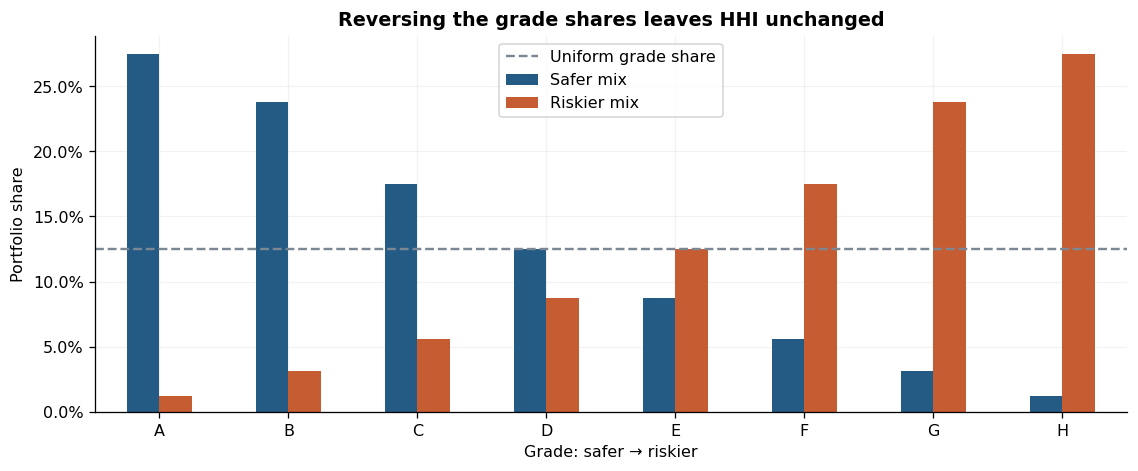

**Result.** Both portfolios have HHI 0.190, compared with the uniform baseline 0.125; implied average PD rises from 2.78% to 13.68%.

In [24]:
initial_counts = pd_spec.n.to_numpy()
shifted_counts = initial_counts[::-1]
initial = grade_frame(initial_counts, GRADES)
shifted = grade_frame(shifted_counts, GRADES)
rows = []
for label, sample in [("Safer mix", initial), ("Riskier mix", shifted)]:
    cv, hhi = m.herfindahl_test(sample, "grade", rating_order=GRADES)
    average_pd = sample.grade.map(dict(zip(GRADES, pd_spec.pd))).mean()
    rows.append({"portfolio": label, "accounts": len(sample), "CV": cv, "HHI": hhi,
                 "effective grades (1/HHI)": 1 / hhi, "implied average PD": average_pd})
counts = pd.DataFrame({"Safer mix": initial_counts, "Riskier mix": shifted_counts}, index=GRADES)
table(counts, caption="Input counts on a fixed A–H grade universe")
table(pd.DataFrame(rows).set_index("portfolio"), {"implied average PD": "{:.2%}"})
fig, ax = plt.subplots()
(counts / counts.sum()).plot.bar(ax=ax, rot=0, color=[BLUE, ORANGE])
ax.axhline(1 / len(GRADES), color=GREY, ls="--", label="Uniform grade share")
ax.set(title="Reversing the grade shares leaves HHI unchanged", xlabel="Grade: safer → riskier",
       ylabel="Portfolio share")
percent(ax); ax.legend(); finish(fig)
report(f"Both portfolios have HHI {rows[0]['HHI']:.3f}, compared with the uniform baseline "
       f"{1/len(GRADES):.3f}; implied average PD rises from {rows[0]['implied average PD']:.2%} "
       f"to {rows[1]['implied average PD']:.2%}.")

**What this shows.** HHI describes concentration, not whether a grade is safe or risky. A permutation of the shares preserves it. The reciprocal gives an intuitive effective number of equally populated grades, while the CV also depends on the stated grade universe. Use a distribution comparison and a risk-mix measure alongside HHI.

**Try changing:** the location of the largest grade share while preserving the count values, or add an explicit empty grade and compare CV with HHI.

<a id="example-22"></a>
### 22. Multiple-period Herfindahl test — more accounts do not improve this statistic

**Question.** Does the reported significance strengthen if both portfolios become ten times larger with the same shares?

The development portfolio has the main cohort’s grade counts. In the current portfolio, 60% of accounts occupy A. Compare the ECB CV statistic for the 8,000-account portfolios and mathematically rescaled 80,000-account portfolios. Also trace its reported tail as the current mix moves progressively toward grade A.

[API, formula and statistical sources](../reference/herfindahl_multiple_period_test.md).

,N_initial,N_current
grade,,
A,2200,4800
B,1900,1000
C,1400,800
D,1000,600
E,700,350
F,450,250
G,250,150
H,100,50


,N_initial,N_current,h_initial,h_current,z_stat,p_value,reject
Original counts,8000,8000,0.1902,0.3945,0.8247,0.205,False
10× all counts,80000,80000,0.1902,0.3945,0.8247,0.205,False


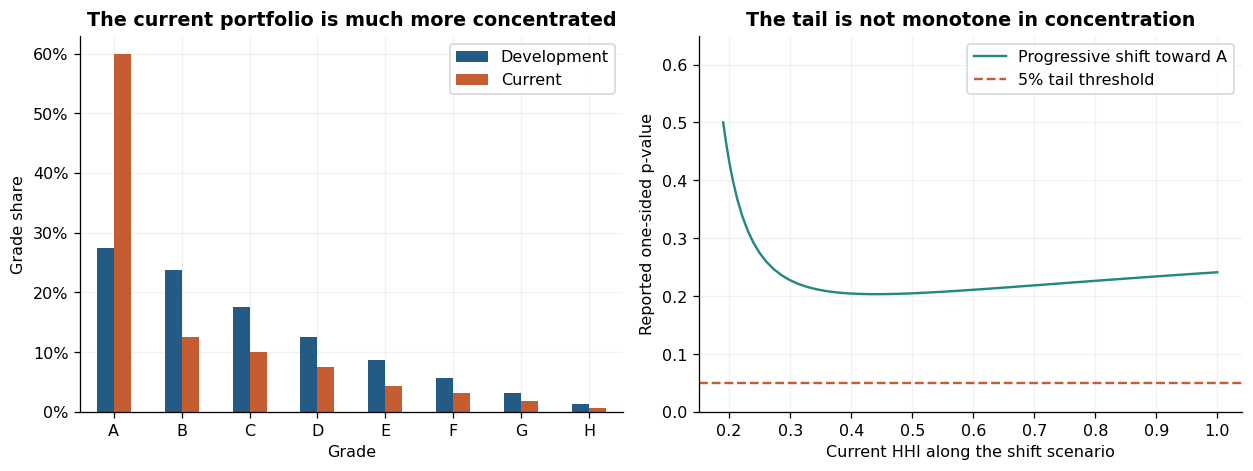

**Result.** HHI rises from 0.190 to 0.395, but p = 0.205. Multiplying all counts by ten leaves z and p unchanged.

In [25]:
initial_counts = pd_spec.n.to_numpy()
current_counts = np.array([4800, 1000, 800, 600, 350, 250, 150, 50])
initial = grade_frame(initial_counts, GRADES)
current = grade_frame(current_counts, GRADES)
result = m.herfindahl_multiple_period_test(initial, current, "grade", rating_order=GRADES)
larger = m.herfindahl_multiple_period_test(grade_frame(initial_counts * 10, GRADES),
    grade_frame(current_counts * 10, GRADES), "grade", rating_order=GRADES)
table(result.loc[GRADES, ["N_initial", "N_current"]], caption="Observed grade counts")
columns = ["N_initial", "N_current", "h_initial", "h_current", "z_stat", "p_value", "reject"]
comparison = pd.DataFrame([result.loc["total", columns], larger.loc["total", columns]],
                          index=["Original counts", "10× all counts"])
table(comparison, {"p_value": "{:.3g}"})
path = []
point_mass = np.array([8000] + [0] * 7)
for fraction in np.linspace(0, 1, 41):
    counts = np.rint((1 - fraction) * initial_counts + fraction * point_mass).astype(int)
    counts[0] += 8000 - counts.sum()
    summary = m.herfindahl_multiple_period_test(initial, grade_frame(counts, GRADES),
        "grade", rating_order=GRADES).loc["total"]
    path.append([summary.h_current, summary.p_value])
path = np.asarray(path, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
pd.DataFrame({"Development": initial_counts / 8000, "Current": current_counts / 8000}, index=GRADES).plot.bar(ax=axes[0], rot=0)
axes[0].set(title="The current portfolio is much more concentrated", xlabel="Grade", ylabel="Grade share")
percent(axes[0])
axes[1].plot(path[:, 0], path[:, 1], color=TEAL, label="Progressive shift toward A")
axes[1].axhline(.05, color=ORANGE, ls="--", label="5% tail threshold")
axes[1].set(title="The tail is not monotone in concentration", xlabel="Current HHI along the shift scenario",
            ylabel="Reported one-sided p-value", ylim=(0, .65))
axes[1].legend(); finish(fig)
report(f"HHI rises from {result.loc['total', 'h_initial']:.3f} to {result.loc['total', 'h_current']:.3f}, "
       f"but p = {result.loc['total', 'p_value']:.3f}. Multiplying all counts by ten leaves z and p unchanged.")

**What this shows.** This specific reference statistic uses the two CVs and the number of grades, not the number of accounts. It is not a conventional two-sample count test, and its tail can become less extreme as concentration increases further. Non-rejection must not override an obvious material shift in the distributions.

**Try changing:** the development mix to a less concentrated nonuniform distribution and inspect how the entire tail curve changes.

<a id="example-23"></a>
### 23. Population stability index — find the grades responsible for a mix shift

**Question.** What detects the reversed portfolio mix that HHI cannot distinguish?

Compare the main count vector with its reversal: 8,000 accounts in development and 8,000 in the current snapshot. Keep the A–H bin boundaries fixed and set the two sample labels explicitly. Every bin has positive counts, so use `smoothing=0` and inspect the unsmoothed contributions.

[API, formula and statistical sources](../reference/population_stability_index.md).

,expected,actual,PSI
grade,,,
A,27.50%,1.25%,0.8114
B,23.75%,3.12%,0.4183
C,17.50%,5.62%,0.1348
D,12.50%,8.75%,0.0134
E,8.75%,12.50%,0.0134
F,5.62%,17.50%,0.1348
G,3.12%,23.75%,0.4183
H,1.25%,27.50%,0.8114


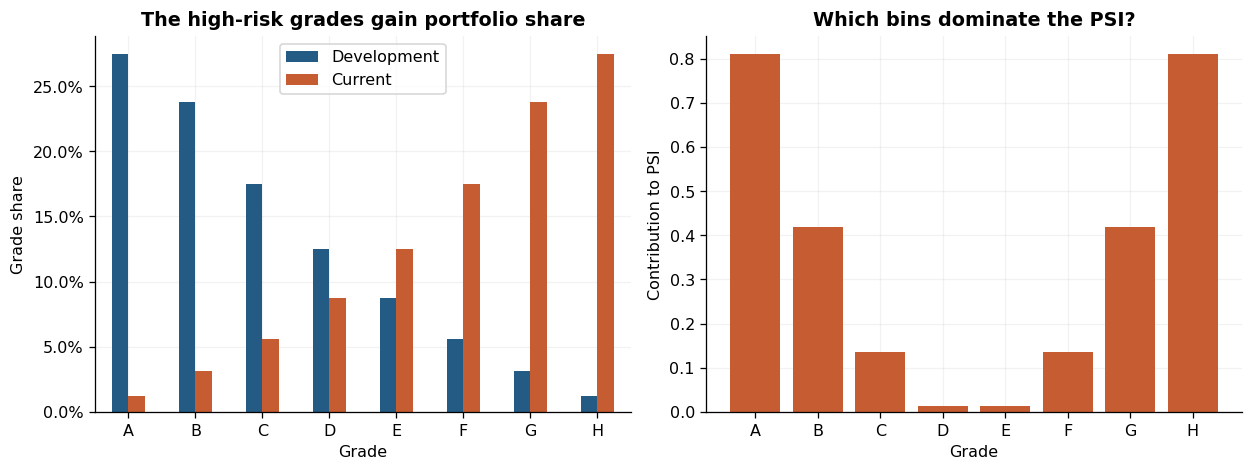

**Result.** PSI = 2.756, even though HHI remains 0.190 → 0.190. A and H together contribute 58.9% of the total.

In [26]:
initial = grade_frame(pd_spec.n.to_numpy(), GRADES).assign(period="development")
current = grade_frame(pd_spec.n.to_numpy()[::-1], GRADES).assign(period="current")
data = pd.concat([initial, current], ignore_index=True)
details, psi = m.population_stability_index(data, "period", "grade", expected="development",
                                            actual="current", smoothing=0, bin_order=GRADES)
table(details, {"expected": "{:.2%}", "actual": "{:.2%}"}, "Grade proportions and contributions")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
details[["expected", "actual"]].rename(columns={"expected": "Development", "actual": "Current"}).plot.bar(ax=axes[0], rot=0)
axes[0].set(title="The high-risk grades gain portfolio share", xlabel="Grade", ylabel="Grade share")
percent(axes[0])
axes[1].bar(GRADES, details.PSI, color=ORANGE)
axes[1].set(title="Which bins dominate the PSI?", xlabel="Grade", ylabel="Contribution to PSI")
finish(fig)
h_initial = m.herfindahl_test(initial, "grade", rating_order=GRADES)[1]
h_current = m.herfindahl_test(current, "grade", rating_order=GRADES)[1]
report(f"PSI = {psi:.3f}, even though HHI remains {h_initial:.3f} → {h_current:.3f}. "
       f"A and H together contribute {(details.loc['A', 'PSI'] + details.loc['H', 'PSI']) / psi:.1%} of the total.")

**What this shows.** PSI compares corresponding bins, so it detects a redistribution that leaves concentration unchanged. It does not identify the cause, establish performance deterioration, or provide a p-value. Follow up on acquisition mix, economic conditions, mapping changes and data quality; the numeric score alone cannot choose among them.

**Try changing:** one grade count to zero and use positive smoothing; disclose how much the pseudo-count changes the result.

<a id="example-24"></a>
### 24. Migration bandwidth — the same migration rate can hide longer jumps

**Question.** If 20% of accounts migrate in both years, can migration behaviour still worsen?

Build two scenarios with 1,000 accounts starting in each of eight performing grades. Both retain 80% on the diagonal. In the local scenario, every move is one grade. In the jump scenario, downgrades move up to three grades while upgrades stay local. A–H runs from lower to higher risk; these are performing grade migrations, with no default absorbing state included.

[API, formula and statistical sources](../reference/migration_matrices_statistics.md).

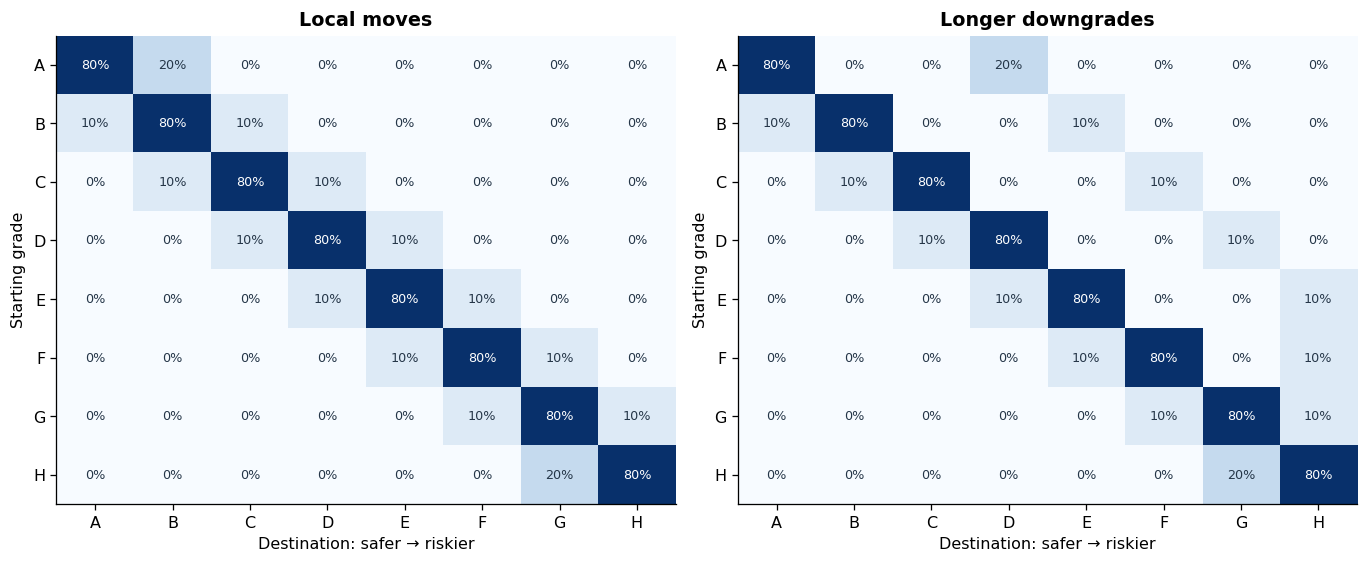

,accounts,migration rate,downgrade bandwidth,upgrade bandwidth
scenario,,,,
Local moves,8000,20.0%,0.1818,0.1818
Longer downgrades,8000,20.0%,0.4773,0.1818


,A,B,C,D,E,F,G,H
A,800,0,0,200,0,0,0,0
B,100,800,0,0,100,0,0,0
C,0,100,800,0,0,100,0,0
D,0,0,100,800,0,0,100,0
E,0,0,0,100,800,0,0,100
F,0,0,0,0,100,800,0,100
G,0,0,0,0,0,100,800,100
H,0,0,0,0,0,0,200,800


**Result.** Both migration rates are 20%, while downgrade bandwidth increases from 0.182 to 0.477.

In [27]:
local = np.eye(8, dtype=int) * 800
jumps = local.copy()
for i in range(8):
    if i > 0:
        amount = 200 if i == 7 else 100
        local[i, i - 1] += amount
        jumps[i, i - 1] += amount
    if i < 7:
        amount = 200 if i == 0 else 100
        local[i, i + 1] += amount
        jumps[i, min(i + 3, 7)] += amount
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, counts in zip(axes, ["Local moves", "Longer downgrades"], [local, jumps]):
    transitions = expand_migrations(counts, GRADES)
    down, up = m.migration_matrices_statistics(transitions, "start", "end", rating_order=GRADES)
    rows.append({"scenario": label, "accounts": len(transitions),
                 "migration rate": 1 - np.trace(counts) / counts.sum(),
                 "downgrade bandwidth": down, "upgrade bandwidth": up})
    heatmap(ax, counts / counts.sum(axis=1, keepdims=True), GRADES, GRADES, label, fmt=".0%", vmin=0, vmax=.8)
    ax.set(xlabel="Destination: safer → riskier", ylabel="Starting grade")
finish(fig)
table(pd.DataFrame(rows).set_index("scenario"), {"migration rate": "{:.1%}"})
table(pd.DataFrame(jumps, index=GRADES, columns=GRADES), caption="Jump-scenario input counts; each row totals 1,000")
report(f"Both migration rates are 20%, while downgrade bandwidth increases from "
       f"{rows[0]['downgrade bandwidth']:.3f} to {rows[1]['downgrade bandwidth']:.3f}.")

**What this shows.** Bandwidth measures distance among directional migrants, not how many accounts migrate. Meliora normalises by each starting grade’s farthest possible distance on the whole scale, even when that farthest endpoint is in the opposite direction. Retain the same ordered grade universe for comparisons; read bandwidth together with the migration rate and matrix.

**Try changing:** the downgrade jump from three grades to two, then separately change the diagonal retention rate.

<a id="example-25"></a>
### 25. Adjacent-cell shape checks — a distant destination gains a suspicious bump

**Question.** Does a migration row have more mass far from the diagonal than one step nearer?

Create an 8 × 8 matrix with 1,000 accounts per starting grade. Probabilities normally taper away from the diagonal, with at least a small count in every cell. In row C, move 130 accounts from C→C to C→F, creating an unusual distant bump. The API returns z-scores and Φ(z), the normal CDF; small CDF values flag local shape reversals, not inequality between two time periods.

[API, formula and statistical sources](../reference/migration_matrix_stability.md).

,A,B,C,D,E,F,G,H
A,790,152,32,9,5,4,4,4
B,132,688,132,28,8,4,4,4
C,27,129,542,129,27,138,4,4
D,8,27,128,670,128,27,8,4
E,4,8,27,128,670,128,27,8
F,4,4,8,27,129,672,129,27
G,4,4,4,8,28,132,688,132
H,4,4,4,5,9,32,152,790


end,A,B,C,D,E,F,G,H
start,,,,,,,,
A,—,1.0000,1.0000,0.9999,0.8576,0.6306,0.5000,0.5000
B,1.0000,—,1.0000,1.0000,0.9996,0.8761,0.5000,0.5000
C,1.0000,1.0000,—,1.0000,1.0000,0.0000,1.0000,0.5000
D,0.9994,1.0000,1.0000,—,1.0000,1.0000,0.9994,0.8761
E,0.8761,0.9994,1.0000,1.0000,—,1.0000,1.0000,0.9994
F,0.5000,0.8761,0.9994,1.0000,1.0000,—,1.0000,1.0000
G,0.5000,0.5000,0.8761,0.9996,1.0000,1.0000,—,1.0000
H,0.5000,0.5000,0.6306,0.8576,0.9999,1.0000,1.0000,—


,start,far destination,near destination,far count,near count,z,normal CDF
0,C,F,E,138,27,-8.9832,1.31e-19


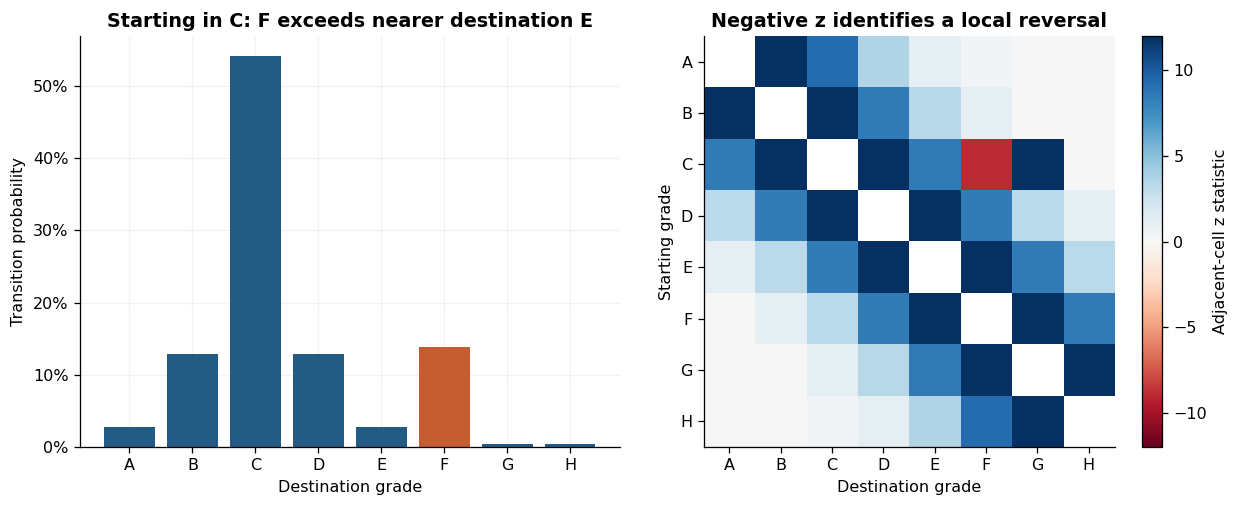

**Result.** C→F has 138 accounts versus 27 for C→E: z = -8.98, Φ(z) = 1.31e-19.

In [28]:
grid = np.arange(8)
weights = np.exp(-np.abs(grid[:, None] - grid[None, :]) / .6) + .006
counts = np.floor(1000 * weights / weights.sum(axis=1, keepdims=True)).astype(int)
for i in range(8):
    counts[i, i] += 1000 - counts[i].sum()
counts[2, 2] -= 130
counts[2, 5] += 130
transitions = expand_migrations(counts, GRADES)
z_scores, normal_cdfs = m.migration_matrix_stability(transitions, "start", "end", rating_order=GRADES)
table(pd.DataFrame(counts, index=GRADES, columns=GRADES), caption="Input transition counts")
table(normal_cdfs, caption="Returned normal CDFs; diagonals are undefined (—)")
flagged = []
for i, j in np.argwhere(normal_cdfs.to_numpy() < .05):
    near = j + 1 if j < i else j - 1
    flagged.append({"start": GRADES[i], "far destination": GRADES[j],
                    "near destination": GRADES[near], "far count": counts[i, j],
                    "near count": counts[i, near], "z": z_scores.iloc[i, j],
                    "normal CDF": normal_cdfs.iloc[i, j]})
table(pd.DataFrame(flagged), {"normal CDF": "{:.3g}"}, "Off-diagonal comparisons below 5% (unadjusted)")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(GRADES, counts[2] / 1000, color=[ORANGE if j == 5 else BLUE for j in range(8)])
axes[0].set(title="Starting in C: F exceeds nearer destination E", xlabel="Destination grade", ylabel="Transition probability")
percent(axes[0])
image = axes[1].imshow(np.ma.masked_invalid(z_scores.to_numpy()), cmap="RdBu", vmin=-12, vmax=12)
axes[1].grid(False)
axes[1].set(xticks=grid, xticklabels=GRADES, yticks=grid, yticklabels=GRADES,
            xlabel="Destination grade", ylabel="Starting grade", title="Negative z identifies a local reversal")
fig.colorbar(image, ax=axes[1], label="Adjacent-cell z statistic")
finish(fig)
report(f"C→F has {counts[2, 5]} accounts versus {counts[2, 4]} for C→E: "
       f"z = {z_scores.loc['C', 'F']:.2f}, Φ(z) = {normal_cdfs.loc['C', 'F']:.3g}.")

**What this shows.** A local bump can motivate investigation of migration rules or a subgroup experiencing a discrete downgrade. These asymptotic multinomial comparisons are unadjusted for many cells; small tail counts weaken their approximation. A diagonal or zero-variance comparison is undefined, not a passed check. Use the row counts to understand the signal before interpreting the tail.

**Try changing:** the injected C→F bump from 130 to 20 or 0; inspect both the visual shape and the reported CDF.

<a id="lgd-validation"></a>
## LGD validation

Separate average bias, monetary loss bias and the size of individual forecast errors.

<a id="example-26"></a>
### 26. LGD t-test — segment biases disappear in the portfolio average

**Question.** Can an apparently unbiased LGD portfolio contain a materially underestimated segment?

Use all 600 completed defaults and then test the three 200-facility segments separately. Each facility receives equal weight, irrespective of EAD. The one-sided alternative is positive mean realised-minus-predicted LGD. For context, plot mean errors with two-sided 95% Student t intervals; these intervals use a different tail allocation from the one-sided tests.

[API, formula and statistical sources](../reference/lgd_t_test.md).

,N,pred_lgd_mean,realised_lgd_mean,mean_error,t_stat,p_value,reject at 5%
segment,,,,,,,
portfolio,600,50.2%,50.2%,+0.00%,0.0000,0.5,False
Commercial secured,200,30.1%,36.1%,+6.00%,16.7881,2.77e-40,True
Unsecured retail,200,50.2%,44.2%,-6.00%,-17.6338,1,False
SME,200,70.3%,70.3%,-0.00%,-0.0000,0.5,False


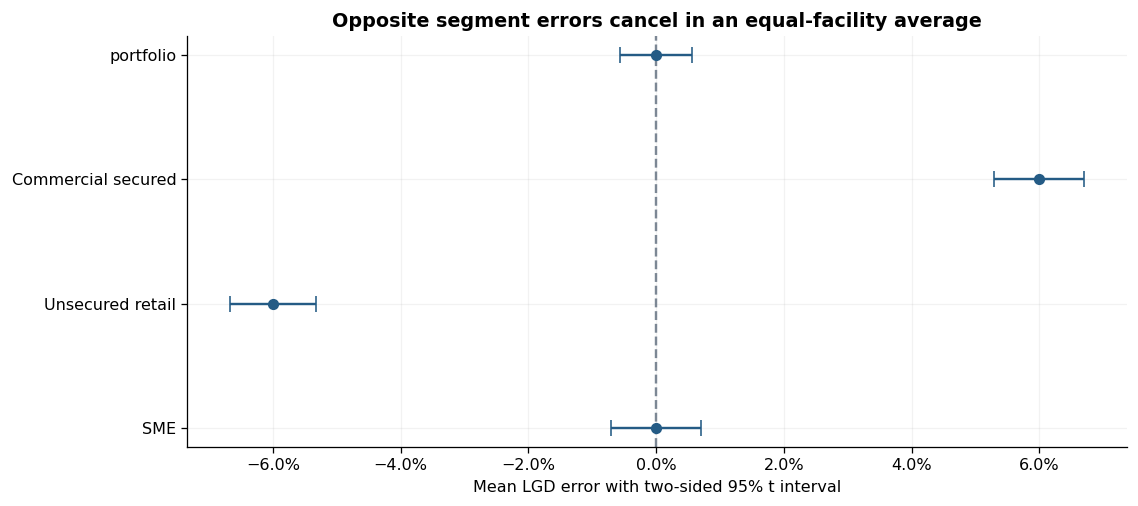

**Result.** Portfolio mean error is +0.00% (p = 0.500); commercial secured has +6 percentage points of mean underestimation, offset by −6 in unsecured retail.

In [29]:
portfolio = m.lgd_t_test(lgd, "realised", "predicted")
segments = m.lgd_t_test(lgd, "realised", "predicted", level="segment", segment_col="segment")
result = pd.concat([portfolio, segments], ignore_index=True).set_index("segment")
result["reject at 5%"] = result.p_value < .05
table(result[["N", "pred_lgd_mean", "realised_lgd_mean", "mean_error", "t_stat", "p_value", "reject at 5%"]],
      {"pred_lgd_mean": "{:.1%}", "realised_lgd_mean": "{:.1%}", "mean_error": "{:+.2%}", "p_value": "{:.3g}"})
half_width = stats.t.ppf(.975, result.N - 1) * np.sqrt(result.s2 / result.N)
fig, ax = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(result))
ax.errorbar(result.mean_error, positions, xerr=half_width, fmt="o", capsize=5, color=BLUE)
ax.axvline(0, ls="--", color=GREY)
ax.set(yticks=positions, yticklabels=result.index, xlabel="Mean LGD error with two-sided 95% t interval",
       title="Opposite segment errors cancel in an equal-facility average")
ax.invert_yaxis(); percent(ax, "x"); finish(fig)
report(f"Portfolio mean error is {portfolio.mean_error.iloc[0]:+.2%} (p = {portfolio.p_value.iloc[0]:.3f}); "
       "commercial secured has +6 percentage points of mean underestimation, offset by −6 in unsecured retail.")

**What this shows.** A portfolio average can conceal actionable segment bias. This test addresses mean error, not individual forecast accuracy or monetary materiality. Segment tests are unadjusted for multiplicity. The displayed inference is the formal calculation for the synthetic data; real interpretation needs suitable independent completed default episodes and sufficiently regular error means.

**Try changing:** segment sizes or biases in a separate copy of the data; distinguish cancellation caused by weights from smaller individual errors.

<a id="example-27"></a>
### 27. ELBE t-test — overestimation matters for a best estimate

**Question.** What changes when the question is any bias, rather than underestimation only?

Use the same 600 outcomes but a fixed best-estimate scenario four LGD percentage points above the original forecast. Treat this as an ELBE forecast frozen at a common reference point, subsequently compared with completed outcomes. Contrast the two-sided ELBE test with a one-sided LGD test using exactly that forecast.

[API, formula and statistical sources](../reference/elbe_t_test.md).

,facilities,lgd_mean,elbe_mean,t_stat,p_value
0,600,50.19%,54.19%,-14.0447,6.14e-39


,p_value
question,
ELBE: any mean bias,6.14e-39
LGD: underestimation only,1


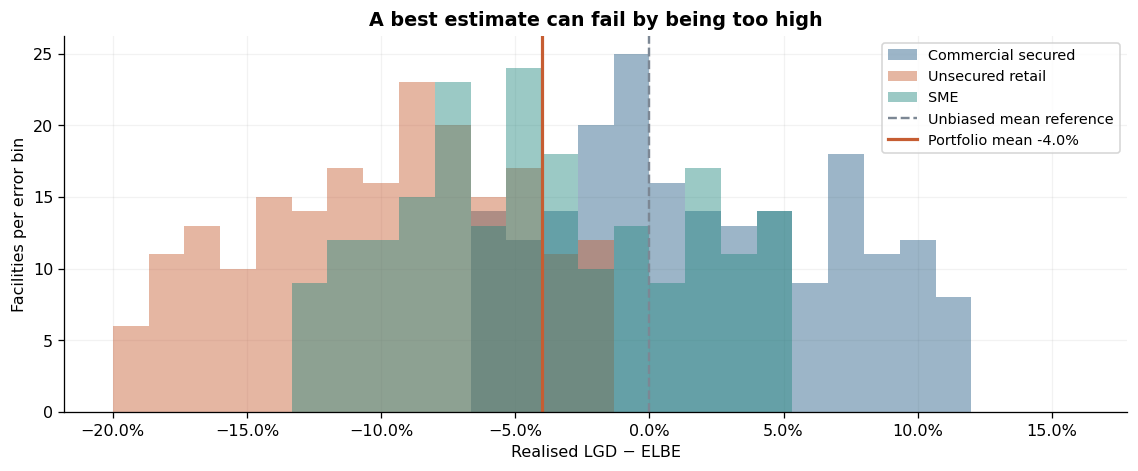

**Result.** ELBE exceeds realised LGD by 4.0 percentage points on average. Two-sided p = 6.14e-39; the underestimation-only p = 1.000.

In [30]:
data = lgd.assign(elbe=lgd.predicted + .04)
result = m.elbe_t_test(data, "realised", "elbe")
one_sided = m.lgd_t_test(data, "realised", "elbe")
errors = data.realised - data.elbe
table(result, {"lgd_mean": "{:.2%}", "elbe_mean": "{:.2%}", "p_value": "{:.3g}"})
comparison = pd.DataFrame({"question": ["ELBE: any mean bias", "LGD: underestimation only"],
                           "p_value": [result.p_value.iloc[0], one_sided.p_value.iloc[0]]})
table(comparison.set_index("question"), {"p_value": "{:.3g}"})
fig, ax = plt.subplots()
for segment, group in data.groupby("segment", sort=False):
    ax.hist(group.realised - group.elbe, bins=np.linspace(-.2, .16, 28), alpha=.45, label=segment)
ax.axvline(0, color=GREY, ls="--", label="Unbiased mean reference")
ax.axvline(errors.mean(), color=ORANGE, lw=2, label=f"Portfolio mean {errors.mean():+.1%}")
ax.set(title="A best estimate can fail by being too high", xlabel="Realised LGD − ELBE", ylabel="Facilities per error bin")
percent(ax, "x"); ax.legend(fontsize=9); finish(fig)
report(f"ELBE exceeds realised LGD by {-100 * errors.mean():.1f} percentage points on average. Two-sided p = "
       f"{result.p_value.iloc[0]:.3g}; the underestimation-only p = {one_sided.p_value.iloc[0]:.3f}.")

**What this shows.** The direction of the question determines the tail. A forecast that is systematically high is not supported as a best estimate by a non-rejection of an underestimation test. Align forecast date, workout horizon and realised loss definition in actual ELBE backtesting; mixing snapshots of the same episode would also compromise the independence of the paired errors.

**Try changing:** the +0.04 ELBE adjustment to −0.04 and compare how the two tails respond.

<a id="example-28"></a>
### 28. Loss shortfall — zero average LGD bias can still cost money

**Question.** What happens when the underestimated segment holds much larger exposures?

Use all 600 original facilities and their EADs. Calculate realised and predicted monetary loss at facility level before aggregating by segment. Loss shortfall divides the net monetary gap by realised monetary loss; it is not an LGD percentage-point error or an equal-facility average.

[API, formula and statistical sources](../reference/loss_shortfall.md).

,ead,predicted_loss,realised_loss,loss_gap,shortfall within segment
segment,,,,,
Commercial secured,"€230,956,300","€70,768,075","€84,020,010","€13,251,935",+15.77%
Unsecured retail,"€36,403,200","€18,286,703","€16,163,919","€-2,122,783",-13.13%
SME,"€74,629,000","€52,587,308","€52,600,439","€13,130",+0.02%


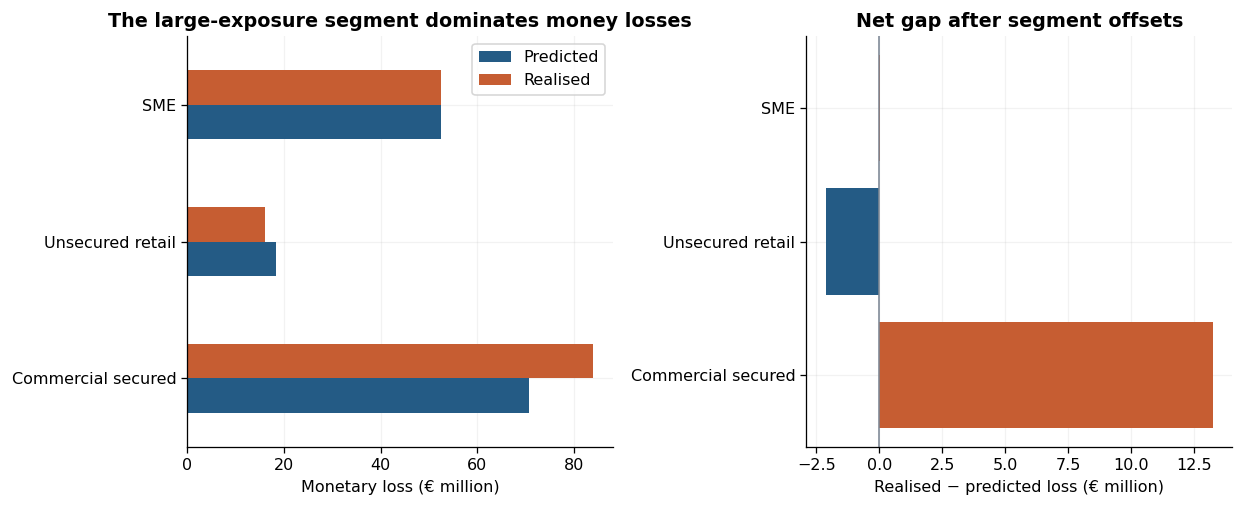

**Result.** Equal-facility mean LGD error is +0.00 percentage points, but the EAD-weighted LGD error is +3.26 points. Net monetary underprediction is €11,142,282, giving loss shortfall 7.29% of realised loss.

In [31]:
data = lgd.assign(predicted_loss=lgd.ead * lgd.predicted, realised_loss=lgd.ead * lgd.realised)
data["loss_gap"] = data.realised_loss - data.predicted_loss
shortfall = m.loss_shortfall(data, "ead", "predicted", "realised")
summary = data.groupby("segment", sort=False)[["ead", "predicted_loss", "realised_loss", "loss_gap"]].sum()
summary["shortfall within segment"] = summary.loss_gap / summary.realised_loss
table(summary, {**{c: "€{:,.0f}" for c in ["ead", "predicted_loss", "realised_loss", "loss_gap"]},
                "shortfall within segment": "{:+.2%}"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
summary[["predicted_loss", "realised_loss"]].div(1e6).rename(
    columns={"predicted_loss": "Predicted", "realised_loss": "Realised"}).plot.barh(ax=axes[0])
axes[0].set(title="The large-exposure segment dominates money losses", xlabel="Monetary loss (€ million)", ylabel="")
axes[1].barh(summary.index, summary.loss_gap / 1e6,
             color=[ORANGE if x > 0 else BLUE for x in summary.loss_gap])
axes[1].axvline(0, color=GREY, lw=1)
axes[1].set(title="Net gap after segment offsets", xlabel="Realised − predicted loss (€ million)")
finish(fig)
weighted_bias = np.average(data.realised - data.predicted, weights=data.ead)
report(f"Equal-facility mean LGD error is {100 * (data.realised - data.predicted).mean():+.2f} percentage points, "
       f"but the EAD-weighted LGD error is {100 * weighted_bias:+.2f} points. Net monetary underprediction is "
       f"€{data.loss_gap.sum():,.0f}, giving loss shortfall {shortfall:.2%} of realised loss.")

**What this shows.** Economic materiality depends on where errors and exposures coincide. The positive shortfall here is compatible with zero equal-facility average bias. Opposite monetary errors can still cancel inside this statistic; the next case isolates that limitation. The ratio is undefined when realised monetary loss is zero, and can be unstable when that denominator is very small.

**Try changing:** all EADs to the same positive amount; compare the monetary result with the equal-facility mean error.

<a id="example-29"></a>
### 29. Exposure-weighted absolute error — matching totals is not enough

**Question.** Can two models have exactly the same total loss and very different facility-level accuracy?

Build a controlled cancellation experiment with 300 matched pairs (600 facilities). Within each pair, exposure and realised LGD are equal. Each model predicts above realised LGD for one member and below it by the same amount for the other. The wide-error model uses 6–18 percentage points; the tighter model uses 1.5–4.5 points. This synthetic symmetry is imposed to expose cancellation, not fitted and presented as a validated forecasting method.

[API, formula and statistical sources](../reference/mean_absolute_deviation.md).

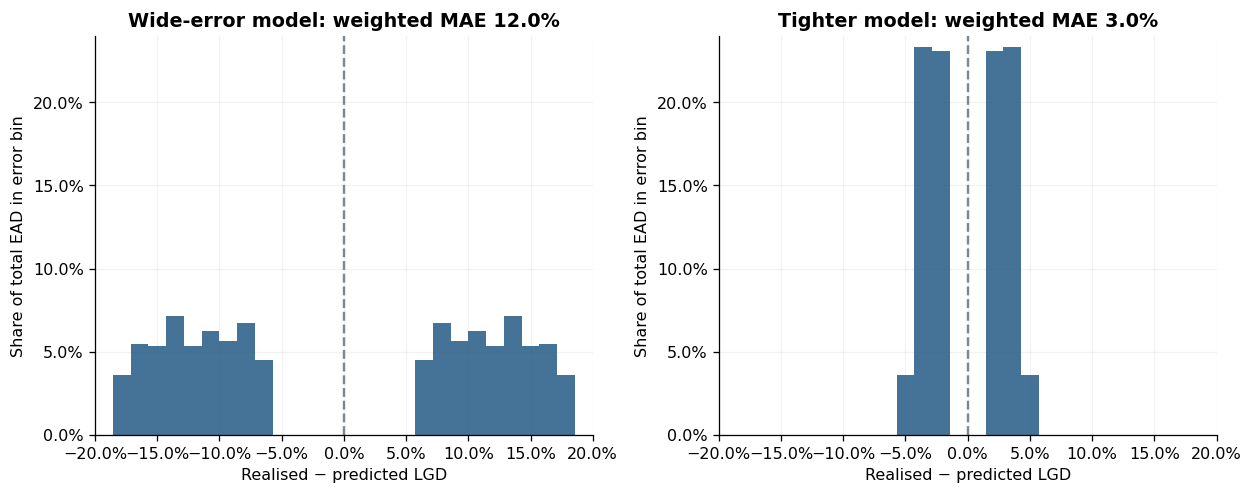

,loss shortfall,EAD-weighted MAE,predicted loss,realised loss
model,,,,
Wide-error model,0.00%,11.96%,"€122,787,775","€122,787,775"
Tighter model,0.00%,2.99%,"€122,787,775","€122,787,775"


,pair,ead,realised,wide,tight
0,0,"€92,516",23.0%,15.8%,21.2%
1,0,"€92,516",23.0%,30.2%,24.8%
2,1,"€86,729",50.4%,34.9%,46.5%
3,1,"€86,729",50.4%,65.9%,54.2%
4,2,"€181,587",51.2%,38.2%,47.9%
5,2,"€181,587",51.2%,64.1%,54.4%
6,3,"€767,952",35.9%,29.3%,34.3%
7,3,"€767,952",35.9%,42.5%,37.6%


**Result.** Both models have zero monetary shortfall (up to rounding), but weighted MAE is 11.96 versus 2.99 LGD percentage points: a fourfold difference.

In [32]:
rng = np.random.default_rng(29)
pair_lgd = rng.uniform(.2, .8, 300)
pair_ead = rng.lognormal(np.log(300_000), .8, 300)
magnitude = rng.uniform(.06, .18, 300)
sign = np.tile([-1, 1], 300)
data = pd.DataFrame({"pair": np.repeat(np.arange(300), 2), "ead": np.repeat(pair_ead, 2),
                     "realised": np.repeat(pair_lgd, 2)})
data["wide"] = data.realised + sign * np.repeat(magnitude, 2)
data["tight"] = data.realised + sign * np.repeat(magnitude / 4, 2)
rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, label, column in zip(axes, ["Wide-error model", "Tighter model"], ["wide", "tight"]):
    mae = m.mean_absolute_deviation(data, "ead", column, "realised")
    shortfall = m.loss_shortfall(data, "ead", column, "realised")
    rows.append({"model": label, "loss shortfall": shortfall, "EAD-weighted MAE": mae,
                 "predicted loss": np.dot(data.ead, data[column]),
                 "realised loss": np.dot(data.ead, data.realised)})
    error = data.realised - data[column]
    ax.hist(error, bins=np.linspace(-.2, .2, 29), weights=data.ead / data.ead.sum(), color=BLUE, alpha=.85)
    ax.axvline(0, color=GREY, ls="--")
    ax.set(title=f"{label}: weighted MAE {mae:.1%}", xlabel="Realised − predicted LGD",
           ylabel="Share of total EAD in error bin", xlim=(-.2, .2), ylim=(0, .24))
    percent(ax, "x"); percent(ax)
finish(fig)
table(pd.DataFrame(rows).set_index("model"), {"loss shortfall": "{:.2%}", "EAD-weighted MAE": "{:.2%}",
      "predicted loss": "€{:,.0f}", "realised loss": "€{:,.0f}"})
table(data.head(8), {"ead": "€{:,.0f}", "realised": "{:.1%}", "wide": "{:.1%}", "tight": "{:.1%}"},
      "First four pairs; all 600 rows enter the calculations")
report(f"Both models have zero monetary shortfall (up to rounding), but weighted MAE is "
       f"{100 * rows[0]['EAD-weighted MAE']:.2f} versus {100 * rows[1]['EAD-weighted MAE']:.2f} LGD percentage points: a fourfold difference.")

**What this shows.** Absolute errors cannot cancel. The weighted MAE is measured in LGD fractions (multiply by 100 for percentage points), while shortfall is relative to realised money loss. Read them together: one measures error magnitude and the other directional aggregate bias. Neither supplies a p-value or a universal acceptance threshold, and the paired construction here is intentionally descriptive.

**Try changing:** the tighter-model divisor from 4 to 2, or break one pair’s EAD symmetry and watch shortfall move independently of MAE.

## What to carry into a validation report

| Finding | Follow-up supported by these examples |
|---|---|
| Strong AUC, Gini or rank correlation | Check numerical calibration and forecast errors; good ordering alone is insufficient. |
| A grade or segment test rejects | Inspect counts, effect size, dependency, and multiple testing before attributing a cause. |
| A portfolio test does not reject | Inspect grades and segments for offsets, low power, or a statistic blind to the issue. |
| HHI stays unchanged | Compare labelled grade shares and implied risk; concentration can hide redistribution. |
| PSI or migration shape changes | Investigate mix, mappings and data quality; drift is not itself measured model deterioration. |
| Total monetary loss is correct | Inspect absolute errors and where exposure sits; totals can conceal large offsetting mistakes. |

These cases use larger inputs to expose mechanisms, not to manufacture evidence
that every test is reliable. Keep the observation unit, forecast horizon, score
direction, grade order, denominator, tail and reference assumptions visible in a
real analysis. Report the practical size of the finding as well as any tail probability.

For smaller API-oriented examples, see the [original notebook](examples.ipynb).
For all signatures, conventions and primary statistical sources, see the
[method reference](../README.md). All 29 public methods have an example above.